# Generate "Execution" workout program with Transformers
https://www.kaggle.com/code/quackaddict7/generate-amazon-book-reviews-with-transformers

## Imports

In [1]:
# Bibliothèques principales
import warnings
import platform
from pathlib import Path
from datetime import datetime
import random
import math
import json
import re

# Imports Python / data science classiques
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

# PyTorch & HuggingFace (version Transformers pour la distillation GPT-2)
import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader, random_split
from torch.optim import AdamW
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
from transformers import pipeline, set_seed, get_scheduler
from tqdm.auto import tqdm


c:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

### Configuration GPU / CPU

In [2]:
warnings.filterwarnings("ignore")

# --- Infos système ---
print("TrAIn.me [Execution Generator] — Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# --- GPU / CPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me [Execution Generator] — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [3]:
# Style "Matplotlib Classic + Accent"
plt.style.use("default")
sns.set_palette("Accent")
pd.set_option('display.max_colWidth', None) # Pour consulter le texte intégral des descriptions

### Header expérimental

In [4]:
# Seeds pour la reproductibilité
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)



OUTPUT_MODEL_NAME = "transformer_execution_generator_v6"
# CHECKPOINT = "distilgpt2"
# CHECKPOINT = "gpt2"   # Teacher = GPT-2 Base (~124M)
# CHECKPOINT = "gpt2-medium"   # Teacher = GPT-2 Medium (345M)

# CHECKPOINT = "gpt2-large"   # À garder pour plus tard --> machine plus musclée ou du cloud.

# CHECKPOINT = "microsoft/DialoGPT-medium"
CHECKPOINT = "microsoft/DialoGPT-large"



# Longueur des séquences
MAX_LENGTH = 256
# Batch & split
BATCH_SIZE = 8
# Nombre d'époques d'entraînement
EPOCHS = 12
LR = 2e-5

### Affichage des versions d'imports

In [5]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
# print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me [Execution Generator] !")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3

Environnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me [Execution Generator] !


## Téléchargement KaggleHub
Ce bloc télécharge les trois datasets et retrouve automatiquement leurs CSV

In [6]:
def load_first_csv_from_kagglehub(dataset_name: str) -> pd.DataFrame:
    """
    Télécharge un dataset via kagglehub et charge automatiquement
    le premier CSV trouvé dans le dossier.
    """
    path = Path(kagglehub.dataset_download(dataset_name))
    csv_files = list(path.rglob("*.csv"))
    
    if not csv_files:
        raise FileNotFoundError(f"Aucun CSV trouvé dans {path}")
    
    print(f"Dataset '{dataset_name}' chargé depuis : {path}")
    print(f"→ CSV utilisé : {csv_files[0].name}")
    
    return pd.read_csv(csv_files[0]), csv_files[0]

# Téléchargement des trois datasets Kaggle
df_gym_exercise_data, file_gym_exercise_data = load_first_csv_from_kagglehub("niharika41298/gym-exercise-data")
df_gym_exercises_dataset, file_gym_exercises_dataset = load_first_csv_from_kagglehub("rishitmurarka/gym-exercises-dataset")
df_best_50_exercise_for_your_body, file_best_50_exercise_for_your_body = load_first_csv_from_kagglehub("prajwaldongre/best-50-exercise-for-your-body")

print("Gym Exercise Dataset:", df_gym_exercise_data.shape)
print("Gym Exercises Dataset:", df_gym_exercises_dataset.shape)
print("Best 50 Exercise for your body:", df_best_50_exercise_for_your_body.shape)

display(df_gym_exercise_data.head(3))
display(df_gym_exercises_dataset.head(3))
display(df_best_50_exercise_for_your_body.head(3))

Dataset 'niharika41298/gym-exercise-data' chargé depuis : C:\Users\fback\.cache\kagglehub\datasets\niharika41298\gym-exercise-data\versions\1
→ CSV utilisé : megaGymDataset.csv
Dataset 'rishitmurarka/gym-exercises-dataset' chargé depuis : C:\Users\fback\.cache\kagglehub\datasets\rishitmurarka\gym-exercises-dataset\versions\1
→ CSV utilisé : gym_exercise_dataset.csv
Dataset 'prajwaldongre/best-50-exercise-for-your-body' chargé depuis : C:\Users\fback\.cache\kagglehub\datasets\prajwaldongre\best-50-exercise-for-your-body\versions\1
→ CSV utilisé : Top 50 Excerice for your body.csv
Gym Exercise Dataset: (2918, 9)
Gym Exercises Dataset: (617, 17)
Best 50 Exercise for your body: (50, 8)


,Unnamed: 0,Title,Desc,Type,BodyPart,Equipment,Level,Rating,RatingDesc
0,0,Partner plank band row,The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.,Strength,Abdominals,Bands,Intermediate,0.0,NaN
1,1,Banded crunch isometric hold,"The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Strength,Abdominals,Bands,Intermediate,NaN,NaN
2,2,FYR Banded Plank Jack,"The banded plank jack is a variation on the plank that involves moving the legs in and out for repetitions. Having a band around the thighs forces the lower body to work harder, particularly the hips and glutes. The plank jack is commonly performed as part of a bodyweight circuit, or as part of a dynamic warm-up.",Strength,Abdominals,Bands,Intermediate,NaN,NaN


,Exercise Name,Equipment,Variation,Utility,Mechanics,Force,Preparation,Execution,Target_Muscles,Synergist_Muscles,Stabilizer_Muscles,Antagonist_Muscles,Dynamic_Stabilizer_Muscles,Main_muscle,Difficulty (1-5),Secondary Muscles,parent_id
0,Neck Flexion,Cable,No,Basic or Auxiliary,Isolated,Pull,Sit on bench facing away from middle pulley. Place neck in harness cable attachment. Place arms on lower thighs for support.,Move head away from pulley by bending neck forward until chin touches upper chest. Return head by hyperextending neck and repeat.,"Sternocleidomastoid,","None,","Rectus Abdominis, Obliques,",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
1,Neck Flexion,Lever (plate loaded),No,Basic or Auxiliary,Isolated,Pull,Sit on seat in machine. Position padded lever on face. Position body so neck is in line with lever axis. Grasp handles for support.,Move head forward by flexing neck until chin touches upper chest. Return head by hyperextending neck and repeat.,"Sternocleidomastoid,","None,","Latissimus Dorsi, Deltoid, Posterior, Rhomboids, Trapezius, Middle, Trapezius, Lower, Triceps Brachii, Rectus Abdominis, Obliques,",NaN,NaN,Neck,2,Sternocleidomastoid,NaN
2,Lateral Neck Flexion,Lever (plate loaded),No,Auxiliary,Isolated,Pull,Sit on seat in machine with feet apart . Position padded lever on side of head. Center body so neck is in line with lever axis. Grasp handles for support.,Move head down to side by laterally flexing neck. Return head to opposite side and repeat. Sit in machine backwards and continue with opposite side.,"Sternocleidomastoid,","Splenius, Erector Spinae, Levator Scapulae, Trapezius, Upper,","Latissimus Dorsi, Pectoralis Major, Sternal, Pectoralis Major, Clavicular, Coracobrachialis, Pectoralis Minor,",NaN,NaN,Neck,2,"Sternocleidomastoid, Levator Scapulae",NaN


,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level
0,Push-ups,3,15,Builds upper body strength,200,"Chest, Triceps, Shoulders",NaN,Intermediate
1,Squats,4,12,Strengthens lower body,223,"Quadriceps, Hamstrings, Glutes",NaN,Beginner
2,Lunges,3,10,Improves balance and coordination,275,"Quadriceps, Hamstrings, Glutes",NaN,Beginner


## Affichage des informations des datasets

In [7]:
# Forme des données et les en-têtes de colonnes
print("Gym Exercise Dataset:\n")
df_gym_exercise_data.info()
print("-------------------------\n")

print("Gym Exercises Dataset:\n")
df_gym_exercises_dataset.info()
print("-------------------------\n")

print("Best 50 Exercise for your body:\n")
df_best_50_exercise_for_your_body.info()
print("-------------------------\n")

Gym Exercise Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2918 entries, 0 to 2917
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2918 non-null   int64  
 1   Title       2918 non-null   object 
 2   Desc        1368 non-null   object 
 3   Type        2918 non-null   object 
 4   BodyPart    2918 non-null   object 
 5   Equipment   2886 non-null   object 
 6   Level       2918 non-null   object 
 7   Rating      1031 non-null   float64
 8   RatingDesc  862 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 205.3+ KB
-------------------------

Gym Exercises Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Exercise Name               617 non-null    object 
 1   Equipment               

## Harmonisation des colonnes

On créé un schéma commun entre les 3 datasets

In [8]:
CANONICAL_COLS = [
    "exercise_name",       # Nom de l'exercice
    "execution",           # Description / Execution
    "target_muscles",      # BodyPart / Target_Muscles / Target muscle Group
    "equipment",           # Equipment / Equipment needed
    "difficulty",          # Level / Difficulty level
    "source_dataset",      # d'où vient la ligne
]

## Preprocessing

### Gym Exercise Dataset (niharika41298)

Définition des colonnes input / output :
- Title → exercise_name
- Desc → execution
- BodyPart → target_muscle
- Equipment → equipment
- Level → difficulty

In [9]:
df_gym_exercise_data = pd.DataFrame({
    "exercise_name":  df_gym_exercise_data["Title"],
    "execution":      df_gym_exercise_data["Desc"],
    "target_muscle": df_gym_exercise_data["BodyPart"],
    "equipment":      df_gym_exercise_data["Equipment"],
    "difficulty":     df_gym_exercise_data["Level"],
})
df_gym_exercise_data["source_dataset"] = "gym_exercise_data_niharika41298"
df_gym_exercise_data.head(10)

,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Partner plank band row,The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.,Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
1,Banded crunch isometric hold,"The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
2,FYR Banded Plank Jack,"The banded plank jack is a variation on the plank that involves moving the legs in and out for repetitions. Having a band around the thighs forces the lower body to work harder, particularly the hips and glutes. The plank jack is commonly performed as part of a bodyweight circuit, or as part of a dynamic warm-up.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
3,Banded crunch,"The banded crunch is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
4,Crunch,"The crunch is a popular core exercise targeting the rectus abdominis, or ""six-pack"" muscles, as well as the obliques. It has been the centerpiece of many ab-focused workouts, due to both its simplicity and the intense burn and mind-muscle connection it produces. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
5,Decline band press sit-up,"The decline band press sit-up is a weighted core exercise that works the rectus abdominis or ""six pack"" muscles, as well as the deep core muscles. It also taxes the muscles of the shoulders and upper back. Sit-up variations with added resistance are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of the core-focused portion of a workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
6,FYR2 Banded Frog Pump,NaN,Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
7,Band low-to-high twist,"The band low-to-high twist is a core exercise targeting the upper abdominals and the obliques. Take care to perform it with control, as rapid, uncontrolled twisting can injure the spine. It is usually performed for moderate to high reps, at least 8-15 per side, as part of the core-focused portion of a workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
8,Barbell roll-out,"The barbell roll-out is an abdominal exercise that utilizes a barbell in the place of an ab roller. It is best performed with a barbell that has rotating collars, and is considered more difficult than other ab roller variations. Many lifters may not be able to perform a single rep at first, but once they can perform these for reps, they'll be rewarded with a seriously strong core.",Abdominals,Barbell,Intermediate,gym_exercise_data_niharika41298
9,Barbell Ab Rollout - On Knees,"The barbell roll-out is an abdominal exercise that utilizes a barbell in the place of an ab roller. It is best performed with a barbell that has rotating collars, and is considered more difficult than other ab roller variations. Many lifters may not be able to perform a single rep at first, but once they can perform these for reps, they'll be rewarded with a seriously strong core.",Abdominals,Barbell,Intermediate,gym_exercise_data_niharika41298


#### Audit qualité

In [10]:
# Audit qualité initial
missing_pct = df_gym_exercise_data.isna().mean().sort_values(ascending=False) * 100
dup_count = df_gym_exercise_data.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df_gym_exercise_data.dtypes.astype(str),
    "n_unique": df_gym_exercise_data.nunique(),
    "missing_%": df_gym_exercise_data.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))

• Doublons détectés (avant): 9


,missing_%
execution,53.118574
equipment,1.096642
exercise_name,0.000000
target_muscle,0.000000
difficulty,0.000000
source_dataset,0.000000


,dtype,n_unique,missing_%
execution,object,1050,53.118574
equipment,object,12,1.096642
exercise_name,object,2909,0.000000
target_muscle,object,17,0.000000
difficulty,object,3,0.000000
source_dataset,object,1,0.000000


#### Doublons & incohérences simples

In [11]:
# Doublons
rows_before = df_gym_exercise_data.shape[0]
dup_total = df_gym_exercise_data.duplicated().sum()
df_gym_exercise_data = df_gym_exercise_data.drop_duplicates().reset_index(drop=True)
rows_after = df_gym_exercise_data.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_gym_exercise_data.shape[1]]
})
display(clean_report)

,rows_before,rows_after,duplicates_removed,cols
0,2918,2909,9,6


#### Suppression des lignes sans "execution"

In [12]:
rows_before = df_gym_exercise_data.shape[0]

df_gym_exercise_data = df_gym_exercise_data[
    df_gym_exercise_data["execution"].notna() &                         # enlève NaN
    (df_gym_exercise_data["execution"].astype(str).str.strip() != "")   # enlève vides
].reset_index(drop=True)

rows_after = df_gym_exercise_data.shape[0]

print(f"Lignes avant  : {rows_before}")
print(f"Lignes après  : {rows_after}")
print(f"Supprimées    : {rows_before - rows_after}")



Lignes avant  : 2909
Lignes après  : 1359
Supprimées    : 1550


In [13]:
df_gym_exercise_data.head(10)

,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Partner plank band row,The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.,Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
1,Banded crunch isometric hold,"The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
2,FYR Banded Plank Jack,"The banded plank jack is a variation on the plank that involves moving the legs in and out for repetitions. Having a band around the thighs forces the lower body to work harder, particularly the hips and glutes. The plank jack is commonly performed as part of a bodyweight circuit, or as part of a dynamic warm-up.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
3,Banded crunch,"The banded crunch is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
4,Crunch,"The crunch is a popular core exercise targeting the rectus abdominis, or ""six-pack"" muscles, as well as the obliques. It has been the centerpiece of many ab-focused workouts, due to both its simplicity and the intense burn and mind-muscle connection it produces. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
5,Decline band press sit-up,"The decline band press sit-up is a weighted core exercise that works the rectus abdominis or ""six pack"" muscles, as well as the deep core muscles. It also taxes the muscles of the shoulders and upper back. Sit-up variations with added resistance are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of the core-focused portion of a workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
6,Band low-to-high twist,"The band low-to-high twist is a core exercise targeting the upper abdominals and the obliques. Take care to perform it with control, as rapid, uncontrolled twisting can injure the spine. It is usually performed for moderate to high reps, at least 8-15 per side, as part of the core-focused portion of a workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
7,Barbell roll-out,"The barbell roll-out is an abdominal exercise that utilizes a barbell in the place of an ab roller. It is best performed with a barbell that has rotating collars, and is considered more difficult than other ab roller variations. Many lifters may not be able to perform a single rep at first, but once they can perform these for reps, they'll be rewarded with a seriously strong core.",Abdominals,Barbell,Intermediate,gym_exercise_data_niharika41298
8,Barbell Ab Rollout - On Knees,"The barbell roll-out is an abdominal exercise that utilizes a barbell in the place of an ab roller. It is best performed with a barbell that has rotating collars, and is considered more difficult than other ab roller variations. Many lifters may not be able to perform a single rep at first, but once they can perform these for reps, they'll be rewarded with a seriously strong core.",Abdominals,Barbell,Intermediate,gym_exercise_data_niharika41298
9,Decline bar press sit-up,"The decline bar press sit-up is a weighted core exercise targeting the abdominal muscles, particularly the lower abs. It also challenges the shoulders and upper back to move the weight. Weighted sit-up variations are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of the core-focused portion of a workou

### Gym Exercises Dataset (rishitmurarka)

Définition des colonnes input / output :
- Exercise Name → exercise_name
- Execution → execution
- Target_Muscles → target_muscles
- Equipement → equipment
- Difficulty (1-5) → difficulty

In [14]:
df_gym_exercises_dataset = pd.DataFrame({
    "exercise_name":  df_gym_exercises_dataset["Exercise Name"],
    "execution":      df_gym_exercises_dataset["Execution"],
    "target_muscle": df_gym_exercises_dataset["Target_Muscles"],
    "equipment":      df_gym_exercises_dataset["Equipment"],
    "difficulty":     df_gym_exercises_dataset["Difficulty (1-5)"],
})
df_gym_exercises_dataset["source_dataset"] = "gym_exercises_data_rishitmurarka"
df_gym_exercises_dataset.head(10)

,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Neck Flexion,Move head away from pulley by bending neck forward until chin touches upper chest. Return head by hyperextending neck and repeat.,"Sternocleidomastoid,",Cable,2,gym_exercises_data_rishitmurarka
1,Neck Flexion,Move head forward by flexing neck until chin touches upper chest. Return head by hyperextending neck and repeat.,"Sternocleidomastoid,",Lever (plate loaded),2,gym_exercises_data_rishitmurarka
2,Lateral Neck Flexion,Move head down to side by laterally flexing neck. Return head to opposite side and repeat. Sit in machine backwards and continue with opposite side.,"Sternocleidomastoid,",Lever (plate loaded),2,gym_exercises_data_rishitmurarka
3,Neck Flexion,Move head forward by flexing neck until chin touches upper chest. Return head by hyperextending neck and repeat.,"Sternocleidomastoid,",Lever (selectorized),2,gym_exercises_data_rishitmurarka
4,Lateral Neck Flexion,Move head down to side by laterally flexing neck. Return head to opposite side and repeat. Sit in machine backwards and continue with opposite side.,"Sternocleidomastoid,",Lever (selectorized),2,gym_exercises_data_rishitmurarka
5,Neck Flexion,Move head up by flexing neck until chin touches upper chest. Return by hyperextending neck and repeat.,"Sternocleidomastoid,",Weighted,2,gym_exercises_data_rishitmurarka
6,Lateral Neck Flexion,Move head up to side by laterally flexing neck. Lower head to opposite side and repeat. Lie on other side and continue.,"Sternocleidomastoid,",Weighted,2,gym_exercises_data_rishitmurarka
7,Wall Front Neck Bridge,Roll down onto forehead until nose touches mat. Roll up onto top of head until chin touches upper chest. Repeat.,"Sternocleidomastoid,",Body Weight,3,gym_exercises_data_rishitmurarka
8,Wall Side Neck Bridge,Push side of head into mat and roll onto top of head moving body away from mat. Return to original position by rolling back down to side of head while bringing shoulder back over end of column or wall. Repeat.,"Sternocleidomastoid,",Body Weight,3,gym_exercises_data_rishitmurarka
9,Neck Flexion,Increase angle of body by bowing head until chin touches upper chest. Lower angle of body by raising head. Repeat.,"Sternocleidomastoid,",Suspended,2,gym_exercises_data_rishitmurarka


#### Audit qualité

In [15]:
# Audit qualité initial
missing_pct = df_gym_exercises_dataset.isna().mean().sort_values(ascending=False) * 100
dup_count = df_gym_exercises_dataset.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df_gym_exercises_dataset.dtypes.astype(str),
    "n_unique": df_gym_exercises_dataset.nunique(),
    "missing_%": df_gym_exercises_dataset.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))

• Doublons détectés (avant): 0


,missing_%
exercise_name,0.0
execution,0.0
target_muscle,0.0
equipment,0.0
difficulty,0.0
source_dataset,0.0


,dtype,n_unique,missing_%
exercise_name,object,340,0.0
execution,object,386,0.0
target_muscle,object,35,0.0
equipment,object,30,0.0
difficulty,int64,5,0.0
source_dataset,object,1,0.0


#### Doublons & incohérences simples

In [16]:
# Doublons
rows_before = df_gym_exercises_dataset.shape[0]
dup_total = df_gym_exercises_dataset.duplicated().sum()
df_gym_exercises_dataset = df_gym_exercises_dataset.drop_duplicates().reset_index(drop=True)
rows_after = df_gym_exercises_dataset.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_gym_exercises_dataset.shape[1]]
})
display(clean_report)

,rows_before,rows_after,duplicates_removed,cols
0,617,617,0,6


#### Suppression des lignes sans "execution"

In [17]:
rows_before = df_gym_exercises_dataset.shape[0]

df_gym_exercises_dataset = df_gym_exercises_dataset[
    df_gym_exercises_dataset["execution"].notna() &                         # enlève NaN
    (df_gym_exercises_dataset["execution"].astype(str).str.strip() != "")   # enlève vides
].reset_index(drop=True)

rows_after = df_gym_exercises_dataset.shape[0]

print(f"Lignes avant  : {rows_before}")
print(f"Lignes après  : {rows_after}")
print(f"Supprimées    : {rows_before - rows_after}")

Lignes avant  : 617
Lignes après  : 617
Supprimées    : 0


#### Nettoyage colonne "target_muscles"

In [18]:
df_gym_exercises_dataset["target_muscle"] = (
    df_gym_exercises_dataset["target_muscle"]
        .astype(str)
        .str.strip()
        .str.rstrip(",")          
        .str.strip()
)
df_gym_exercises_dataset["target_muscle"].head(10)

0    Sternocleidomastoid
1    Sternocleidomastoid
2    Sternocleidomastoid
3    Sternocleidomastoid
4    Sternocleidomastoid
5    Sternocleidomastoid
6    Sternocleidomastoid
7    Sternocleidomastoid
8    Sternocleidomastoid
9    Sternocleidomastoid
Name: target_muscle, dtype: object

#### Harmonisation colonne "difficulty"
Règle pour les notes 1–5 :
- 1–2 → "Beginner"
- 3 → "Intermediate"
- 4–5 → "Expert"

In [19]:
# Harmonisation de la difficulté dans df_gym_exercises_dataset
# (colonne numérique 1–5 → "Beginner" / "Intermediate" / "Expert")

def map_numeric_difficulty(val):
    if pd.isna(val):
        return None
    
    # Gestion des formats type "1\n2\n3" ou "1, 2, 3"
    text = str(val).replace("\n", ",")
    parts = [p.strip() for p in text.split(",") if p.strip()]
    
    scores = []
    for p in parts:
        try:
            scores.append(int(float(p)))
        except ValueError:
            continue
    
    if not scores:
        return None
    
    score = max(scores)  # on garde le niveau le plus élevé

    if score <= 2:
        return "Beginner"
    elif score == 3:
        return "Intermediate"
    else:  # 4 ou 5
        return "Expert"

df_gym_exercises_dataset["difficulty"] = df_gym_exercises_dataset["difficulty"].apply(map_numeric_difficulty)

# Petit check
print(df_gym_exercises_dataset["difficulty"].value_counts(dropna=False))


difficulty
Intermediate    254
Beginner        250
Expert          113
Name: count, dtype: int64


In [20]:
df_gym_exercises_dataset.head(10)

,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Neck Flexion,Move head away from pulley by bending neck forward until chin touches upper chest. Return head by hyperextending neck and repeat.,Sternocleidomastoid,Cable,Beginner,gym_exercises_data_rishitmurarka
1,Neck Flexion,Move head forward by flexing neck until chin touches upper chest. Return head by hyperextending neck and repeat.,Sternocleidomastoid,Lever (plate loaded),Beginner,gym_exercises_data_rishitmurarka
2,Lateral Neck Flexion,Move head down to side by laterally flexing neck. Return head to opposite side and repeat. Sit in machine backwards and continue with opposite side.,Sternocleidomastoid,Lever (plate loaded),Beginner,gym_exercises_data_rishitmurarka
3,Neck Flexion,Move head forward by flexing neck until chin touches upper chest. Return head by hyperextending neck and repeat.,Sternocleidomastoid,Lever (selectorized),Beginner,gym_exercises_data_rishitmurarka
4,Lateral Neck Flexion,Move head down to side by laterally flexing neck. Return head to opposite side and repeat. Sit in machine backwards and continue with opposite side.,Sternocleidomastoid,Lever (selectorized),Beginner,gym_exercises_data_rishitmurarka
5,Neck Flexion,Move head up by flexing neck until chin touches upper chest. Return by hyperextending neck and repeat.,Sternocleidomastoid,Weighted,Beginner,gym_exercises_data_rishitmurarka
6,Lateral Neck Flexion,Move head up to side by laterally flexing neck. Lower head to opposite side and repeat. Lie on other side and continue.,Sternocleidomastoid,Weighted,Beginner,gym_exercises_data_rishitmurarka
7,Wall Front Neck Bridge,Roll down onto forehead until nose touches mat. Roll up onto top of head until chin touches upper chest. Repeat.,Sternocleidomastoid,Body Weight,Intermediate,gym_exercises_data_rishitmurarka
8,Wall Side Neck Bridge,Push side of head into mat and roll onto top of head moving body away from mat. Return to original position by rolling back down to side of head while bringing shoulder back over end of column or wall. Repeat.,Sternocleidomastoid,Body Weight,Intermediate,gym_exercises_data_rishitmurarka
9,Neck Flexion,Increase angle of body by bowing head until chin touches upper chest. Lower angle of body by raising head. Repeat.,Sternocleidomastoid,Suspended,Beginner,gym_exercises_data_rishitmurarka


### Best 50 Exercise for your body (prajwaldongre)

Ce dataset ne contient pas de colonne descriptive, on pourra s'en servir pour le remplir automatiquement.

Définition des colonnes input / output :
- Name of Exercise → exercise_name
- Description → execution
- BodyPart → target_muscles
- Equipment → equipment
- Level → difficulty

Dans ce dataset, Equipment Needed = "None" signifie que l’exercice peut être réalisé sans aucun équipement.
Donc ce sont des bodyweight exercises, c’est-à-dire des exercices au poids du corps :
- Push-ups → bodyweight
- Squats (sans précision) → bodyweight
- Lunges → bodyweight
- Burpees → bodyweight
- Mountain climbers → bodyweight
- Jumping jacks → bodyweight
- Bicycle crunches → bodyweight

In [21]:
df_best_50_exercise_for_your_body = pd.DataFrame({
    "exercise_name":  df_best_50_exercise_for_your_body["Name of Exercise"],
    # pas de description dans ce dataset
    "execution":      pd.NA,
    "target_muscle": df_best_50_exercise_for_your_body["Target Muscle Group"],
    # harmonisation de l'équipement : None -> Bodyweight
    "equipment":      df_best_50_exercise_for_your_body["Equipment Needed"]
                           .replace({"None": "Bodyweight"})
                           .fillna("Bodyweight"),
    "difficulty":     df_best_50_exercise_for_your_body["Difficulty Level"],
})

df_best_50_exercise_for_your_body["source_dataset"] = "best_50_exercises_prajwaldongre"

df_best_50_exercise_for_your_body.head(10)


,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Push-ups,<NA>,"Chest, Triceps, Shoulders",Bodyweight,Intermediate,best_50_exercises_prajwaldongre
1,Squats,<NA>,"Quadriceps, Hamstrings, Glutes",Bodyweight,Beginner,best_50_exercises_prajwaldongre
2,Lunges,<NA>,"Quadriceps, Hamstrings, Glutes",Bodyweight,Beginner,best_50_exercises_prajwaldongre
3,Burpees,<NA>,Full Body,Bodyweight,Advanced,best_50_exercises_prajwaldongre
4,Mountain Climbers,<NA>,"Core, Shoulders, Legs",Bodyweight,Intermediate,best_50_exercises_prajwaldongre
5,Jumping Jacks,<NA>,Full Body,Bodyweight,Beginner,best_50_exercises_prajwaldongre
6,Bicycle Crunches,<NA>,Core,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
7,Dips,<NA>,"Triceps, Chest",Parallel Bars or Chair,Intermediate,best_50_exercises_prajwaldongre
8,Pull-ups,<NA>,"Back, Biceps",Pull-up Bar,Advanced,best_50_exercises_prajwaldongre
9,Russian Twists,<NA>,"Core, Obliques",None or Dumbbell,Intermediate,best_50_exercises_prajwaldongre


#### Audit qualité

In [22]:
# Audit qualité initial
missing_pct = df_best_50_exercise_for_your_body.isna().mean().sort_values(ascending=False) * 100
dup_count = df_best_50_exercise_for_your_body.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df_best_50_exercise_for_your_body.dtypes.astype(str),
    "n_unique": df_best_50_exercise_for_your_body.nunique(),
    "missing_%": df_best_50_exercise_for_your_body.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))

• Doublons détectés (avant): 0


,missing_%
execution,100.0
exercise_name,0.0
target_muscle,0.0
equipment,0.0
difficulty,0.0
source_dataset,0.0


,dtype,n_unique,missing_%
execution,object,0,100.0
exercise_name,object,50,0.0
target_muscle,object,35,0.0
equipment,object,21,0.0
difficulty,object,3,0.0
source_dataset,object,1,0.0


#### Doublons & incohérences simples

In [23]:
# Doublons
rows_before = df_best_50_exercise_for_your_body.shape[0]
dup_total = df_best_50_exercise_for_your_body.duplicated().sum()
df_best_50_exercise_for_your_body = df_best_50_exercise_for_your_body.drop_duplicates().reset_index(drop=True)
rows_after = df_best_50_exercise_for_your_body.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_best_50_exercise_for_your_body.shape[1]]
})
display(clean_report)

,rows_before,rows_after,duplicates_removed,cols
0,50,50,0,6


#### Dupliquer les lignes pour chaque muscle

In [24]:
df_exploded = df_best_50_exercise_for_your_body.copy()

# Split sur la virgule → liste de muscles
df_exploded["target_muscle"] = (
    df_exploded["target_muscle"]
        .astype(str)
        .str.split(",")
)

# Explode : une ligne par muscle
df_exploded = df_exploded.explode("target_muscle").reset_index(drop=True)

# Nettoyage des espaces / valeurs vides
df_exploded["target_muscle"] = (
    df_exploded["target_muscle"]
        .astype(str)
        .str.strip()
)
df_exploded = df_exploded[df_exploded["target_muscle"] != ""].reset_index(drop=True)

# Renommer l'exercice en ajoutant le muscle entre parenthèses
df_exploded["exercise_name"] = (
    df_exploded["exercise_name"].astype(str).str.strip()
    + " (" + df_exploded["target_muscle"] + ")"
)

# Petit contrôle
display(df_exploded.head(10))
print("Shape avant :", df_best_50_exercise_for_your_body.shape)
print("Shape après :", df_exploded.shape)

df_best_50_exercise_for_your_body = df_exploded

,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Push-ups (Chest),<NA>,Chest,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
1,Push-ups (Triceps),<NA>,Triceps,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
2,Push-ups (Shoulders),<NA>,Shoulders,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
3,Squats (Quadriceps),<NA>,Quadriceps,Bodyweight,Beginner,best_50_exercises_prajwaldongre
4,Squats (Hamstrings),<NA>,Hamstrings,Bodyweight,Beginner,best_50_exercises_prajwaldongre
5,Squats (Glutes),<NA>,Glutes,Bodyweight,Beginner,best_50_exercises_prajwaldongre
6,Lunges (Quadriceps),<NA>,Quadriceps,Bodyweight,Beginner,best_50_exercises_prajwaldongre
7,Lunges (Hamstrings),<NA>,Hamstrings,Bodyweight,Beginner,best_50_exercises_prajwaldongre
8,Lunges (Glutes),<NA>,Glutes,Bodyweight,Beginner,best_50_exercises_prajwaldongre
9,Burpees (Full Body),<NA>,Full Body,Bodyweight,Advanced,best_50_exercises_prajwaldongre


Shape avant : (50, 6)
Shape après : (106, 6)


In [25]:
df_best_50_exercise_for_your_body.head(10)

,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Push-ups (Chest),<NA>,Chest,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
1,Push-ups (Triceps),<NA>,Triceps,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
2,Push-ups (Shoulders),<NA>,Shoulders,Bodyweight,Intermediate,best_50_exercises_prajwaldongre
3,Squats (Quadriceps),<NA>,Quadriceps,Bodyweight,Beginner,best_50_exercises_prajwaldongre
4,Squats (Hamstrings),<NA>,Hamstrings,Bodyweight,Beginner,best_50_exercises_prajwaldongre
5,Squats (Glutes),<NA>,Glutes,Bodyweight,Beginner,best_50_exercises_prajwaldongre
6,Lunges (Quadriceps),<NA>,Quadriceps,Bodyweight,Beginner,best_50_exercises_prajwaldongre
7,Lunges (Hamstrings),<NA>,Hamstrings,Bodyweight,Beginner,best_50_exercises_prajwaldongre
8,Lunges (Glutes),<NA>,Glutes,Bodyweight,Beginner,best_50_exercises_prajwaldongre
9,Burpees (Full Body),<NA>,Full Body,Bodyweight,Advanced,best_50_exercises_prajwaldongre


## Fusion (df_gym_exercise_data et df_gym_exercises_dataset) + nettoyage

La fusion se fait sur "Gym Exercise Dataset (niharika41298)" et "Best 50 Exercise for your body (prajwaldongre)" avec des valeurs dans la colonne "execution" --> c'est notre base d'entraînement.

On laisse "Best 50 Exercise for your body (prajwaldongre)" de côté pour le moment

In [26]:
df_execution_generator = pd.concat([df_gym_exercise_data, df_gym_exercises_dataset], ignore_index=True)

# trim espaces, mettre en lower pour certains champs
for col in ["exercise_name", "target_muscle", "equipment", "difficulty"]:
    df_execution_generator[col] = (
        df_execution_generator[col]
        .astype("string")
        .str.strip()
    )

# Optionnel : supprimer les doublons sur nom + muscles
df_all_unique = df_execution_generator.drop_duplicates(
    subset=["exercise_name", "target_muscle", "equipment"],
    keep="first"
).reset_index(drop=True)

print("Shape fusion brute :", df_execution_generator.shape)
print("Shape après dédoublonnage :", df_all_unique.shape)

df_execution_generator = df_all_unique
df_execution_generator.head(20)

Shape fusion brute : (1976, 6)
Shape après dédoublonnage : (1976, 6)


,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
0,Partner plank band row,The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.,Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
1,Banded crunch isometric hold,"The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
2,FYR Banded Plank Jack,"The banded plank jack is a variation on the plank that involves moving the legs in and out for repetitions. Having a band around the thighs forces the lower body to work harder, particularly the hips and glutes. The plank jack is commonly performed as part of a bodyweight circuit, or as part of a dynamic warm-up.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
3,Banded crunch,"The banded crunch is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
4,Crunch,"The crunch is a popular core exercise targeting the rectus abdominis, or ""six-pack"" muscles, as well as the obliques. It has been the centerpiece of many ab-focused workouts, due to both its simplicity and the intense burn and mind-muscle connection it produces. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
5,Decline band press sit-up,"The decline band press sit-up is a weighted core exercise that works the rectus abdominis or ""six pack"" muscles, as well as the deep core muscles. It also taxes the muscles of the shoulders and upper back. Sit-up variations with added resistance are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of the core-focused portion of a workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
6,Band low-to-high twist,"The band low-to-high twist is a core exercise targeting the upper abdominals and the obliques. Take care to perform it with control, as rapid, uncontrolled twisting can injure the spine. It is usually performed for moderate to high reps, at least 8-15 per side, as part of the core-focused portion of a workout.",Abdominals,Bands,Intermediate,gym_exercise_data_niharika41298
7,Barbell roll-out,"The barbell roll-out is an abdominal exercise that utilizes a barbell in the place of an ab roller. It is best performed with a barbell that has rotating collars, and is considered more difficult than other ab roller variations. Many lifters may not be able to perform a single rep at first, but once they can perform these for reps, they'll be rewarded with a seriously strong core.",Abdominals,Barbell,Intermediate,gym_exercise_data_niharika41298
8,Barbell Ab Rollout - On Knees,"The barbell roll-out is an abdominal exercise that utilizes a barbell in the place of an ab roller. It is best performed with a barbell that has rotating collars, and is considered more difficult than other ab roller variations. Many lifters may not be able to perform a single rep at first, but once they can perform these for reps, they'll be rewarded with a seriously strong core.",Abdominals,Barbell,Intermediate,gym_exercise_data_niharika41298
9,Decline bar press sit-up,"The decline bar press sit-up is a weighted core exercise targeting the abdominal muscles, particularly the lower abs. It also challenges the shoulders and upper back to move the weight. Weighted sit-up variations are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of the core-focused portion of a workou

### Cohérence "Bodyweight" / "Body Only" / "Body Weight"

In [27]:
subset_body_only = df_execution_generator[df_execution_generator["equipment"] == "Body Only"]

print("Nombre d'exercices Body Only :", subset_body_only.shape[0])
display(subset_body_only.head(20))

Nombre d'exercices Body Only : 404


,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
88,Elbow plank,"The elbow plank is a popular isometric abdominal exercise. It is common in all types of exercise programs, as well as in group fitness and yoga classes. It targets the muscles of the core, the deep core or transversus abdominis in particular. It is also often prescribed for time to help back pain or to teach proper bracing.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
89,Bottoms Up,"The lying leg lift is a popular bodyweight exercise targeting the muscles of the abs, the rectus abdominis or “six-pack” muscles in particular. It can be performed for time or reps in the core-focused portion of any workout.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
90,Spider crawl,"The spider crawl is a bodyweight exercise that involves crawling on the floor with the knees outside of the elbows. It is different from a leopard crawl in that the hips are higher, and it's different from a bear crawl because the knees are wider. It can be done as a full-body warm-up, in short bursts for power or circuit training, or for longer durations as cardiovascular conditioning.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
91,Cocoons,"The cocoon crunch is a bodyweight exercise targeting the ab muscles, the rectus abdominis or ""six-pack"" muscles in particular. It involves bringing your knees to your chest and your arms from overhead to center. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
92,Cross-Body Crunch,"The elbow-to-knee crunch is a bodyweight exercise targeting the ab muscles, the obliques and rectus abdominis or ""six-pack"" muscles in particular. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
93,Elbow-to-knee crunch,"The elbow-to-knee crunch is a bodyweight exercise targeting the ab muscles, the obliques and rectus abdominis or ""six-pack"" muscles in particular. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
94,Decline Crunch,The decline crunch is an effective core exercise targeting the rectus abdominis.,Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
95,Hanging toes-to-bar,"The hanging toes-to-bar is an advanced abdominal exercise in which the lifter touches their feet to a pull-up bar. There are many ways to perform this movement (strict or swinging, arms completely straight or slightly bent, legs straight or bent) each providing unique benefits and challenges. Initially, it may be a difficult move to do for a single rep, but once you build the requisite core, lat, and shoulder strength, it can be performed for higher reps.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
96,Hanging Oblique Knee Raise,"The hanging oblique crunch an abdominal exercise that targets both the rectus abdominus or “six-pack” muscles, and the oblique muscles. It can be performed hanging from a bar, or if grip strength is a limitation, by placing the elbows in ab straps. If hanging from a straight bar is uncomfortable to the wrists or shoulder, you can also perform them hanging with a neutral grip (palms facing one another)",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298
97,Hanging leg raise,"The hanging leg raise is an exercise targeting the abs, but which also works the lats and hip flexors. Instead of resting your forearms on the pads of a captain's chair, you perform these hanging from a bar. Experienced lifters make these look easy, but beginners may need time to build up to sets of 8-12 reps.",Abdominals,Body Only,Intermediate,gym_exercise_data_niharika41298


In [28]:
subset_body_only = df_execution_generator[df_execution_generator["equipment"] == "Body Weight"]

print("Nombre d'exercices Body Weight :", subset_body_only.shape[0])
display(subset_body_only.head(20))

Nombre d'exercices Body Weight : 76


,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
1366,Wall Front Neck Bridge,Roll down onto forehead until nose touches mat. Roll up onto top of head until chin touches upper chest. Repeat.,Sternocleidomastoid,Body Weight,Intermediate,gym_exercises_data_rishitmurarka
1367,Wall Side Neck Bridge,Push side of head into mat and roll onto top of head moving body away from mat. Return to original position by rolling back down to side of head while bringing shoulder back over end of column or wall. Repeat.,Sternocleidomastoid,Body Weight,Intermediate,gym_exercises_data_rishitmurarka
1376,Wall Rear Neck Bridge,Push head back into mat and roll head upward. Arch spine and straighten knees. Hyperextend neck so head is facing up. Return to original position by rolling head down while allowing low back to straighten and knees to bend slightly. Continue down until back of head and shoulders make contact with mat. Repeat.,Splenius,Body Weight,Intermediate,gym_exercises_data_rishitmurarka
1400,Pike Press (between benches),Lower head between ends of benches by bending arms. Push body back up to original position by extending arms. Repeat.,Anterior Deltoid,Body Weight,Expert,gym_exercises_data_rishitmurarka
1401,Pike Press (between benches): Elevated (between benches),Lower head between ends of benches by bending arms. Push body back up to original position by extending arms. Repeat.,Anterior Deltoid,Body Weight,Expert,gym_exercises_data_rishitmurarka
1435,Rear Delt Inverted Row (high bar),"Lower body while keeping body straight, elbows high, and upper arms perpendicular to torso, until arms are extended straight. Pull shoulders toward bar while keeping elbows up high until upper arms are parallel to one another, or just beyond. Repeat.",Posterior Deltoid,Body Weight,Expert,gym_exercises_data_rishitmurarka
1436,Rear Delt Inverted Row (on hips),"Keeping hips on floor, low back straight, and elbow pointed out to sides; pull torso up to bar. Return when upper arms are just beyond parallel to one another. Lower body downward until arms are extended straight. Return and repeat.",Posterior Deltoid,Body Weight,Expert,gym_exercises_data_rishitmurarka
1473,Bench Dip,"Lower body by bending arms until slight stretch is felt in chest or shoulder, or rear end touches floor. Raise body and repeat.",Triceps Brachii,Body Weight,Intermediate,gym_exercises_data_rishitmurarka
1474,Bench Dip: heel on floor,"Lower body by bending arms until slight stretch is felt in chest or shoulder, or rear end touches floor. Raise your body and repeat.",Triceps Brachii,Body Weight,Beginner,gym_exercises_data_rishitmurarka
1475,Close Grip Push-up,"Keeping body straight, lower body to floor by bending arms. Push body up until arms are extended. Repeat.",Triceps Brachii,Body Weight,Intermediate,gym_exercises_data_rishitmurarka


In [29]:
df_execution_generator["equipment"] = (
    df_execution_generator["equipment"]
        .astype(str).str.strip()
        .replace({
            "Body Only": "Bodyweight",
            "Body Weight": "Bodyweight",
            "Body-Weight": "Bodyweight",
            "None": "Bodyweight",
            "none": "Bodyweight",
            "body only": "Bodyweight",
            "body weight": "Bodyweight",
            "Other": "Bodyweight",
            "<NA>": "Bodyweight",
        })
)

In [30]:
print(df_execution_generator["equipment"].value_counts())

equipment
Bodyweight                         590
Dumbbell                           305
Cable                              247
Barbell                            217
Machine                            121
Lever (selectorized)                80
Lever (plate loaded)                76
Kettlebells                         53
Bands                               47
Weighted                            34
Suspended                           31
Sled                                31
Exercise Ball                       28
Medicine Ball                       25
Smith                               21
E-Z Curl Bar                        14
Foam Roll                            8
Band-assisted                        7
Self-assisted                        6
Self-assisted​​​​​​​                 5
Lever (selectorized)​​​​​​​          4
Assisted                             4
Assisted (machine)                   3
Lever                                3
Assisted (partner)                   2
Suspension     

In [31]:
subset_body_only = df_execution_generator[df_execution_generator["equipment"] == "Bodyweight"]

print("Nombre d'exercices Body Only :", subset_body_only.shape[0])
display(subset_body_only.head(20))

Nombre d'exercices Body Only : 590


,exercise_name,execution,target_muscle,equipment,difficulty,source_dataset
37,Landmine twist,"The landmine twist is a rotational abdominal movement performed using an angled barbell anchored at floor level in a landmine device. It can also be performed by sticking a barbell in the corner of a room, preferably in a towel to protect the walls. It targets the deep muscles of the core, including both the obliques and the transversus abdominis. It can be done fast or slow, for time or reps, either in traditional muscle-focused rep ranges such as 8-12 reps per side or for higher rep ranges.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
38,Suspended ab fall-out,"The suspended ab fall-out is a dynamic abdominal exercise utilizing a suspension strap system or gymnastic rings. It is similar in form to an ab roller, but can more easily be scaled to be more or less difficult. It targets the muscles of the rectus abdominis or ""six-pack"" muscles, as well as the deep core muscles. It can be trained for low reps for strength or higher reps for muscle definition.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
39,Decline reverse crunch,"The decline reverse crunch is a popular bodyweight exercise targeting the abdominal muscles, particularly the lower abs. It is usually performed for high reps, such as 10-15 reps per set or more, as part of the ab-focused portion of a workout.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
40,Weighted Crunches,"The weighted suitcase crunch is a weighted version of a popular abdominal training exercise. The simple addition of a weight makes the suitcase crunch far more difficult, helping build the ""six pack"" muscles and providing a different stimulus to the core during training.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
41,Ab Roller,"The ab wheel roll-out is an exercise targeting the abdominals, often with an inexpensive wheel device with a handle on either side. Many trainers and strength coaches claim it's one of, if no the best exercise for developing strength in the midsection. Beginners may have to start with a limited range of motion or just wheel planks.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
42,Otis-Up,"The Otis-up is a weighted exercise focusing on the abdominal muscles, as well as the shoulders to a lesser degree. It primarily targets the rectus abdominus or “six-pack” muscles, but also involves the obliques and deep core muscles. It is normally performed on a decline bench holding a weight plate, but can also be performed with a dumbbell, kettlebell, or other weight.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
43,Captain's chair knee raise,"The captain's chair knee raise is a bodyweight exercise that targets the abs. It is performed on an apparatus that allows the forearms to rest on pads and the upright torso to hang freely. Knee raises are often performed for moderate to high reps, such as 8-12 reps or more, as part of ab-focused training.",Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
44,Sledgehammer swing,The sledgehammer swing is an exercise working the abdominals and numerous other muscles. The sledgehammer is slammed from overhead onto a tire which absorbs the impact and causes the hammer to bounce back up. It can be performed for time or reps as part of a functional fitness or athleticism-focused workout.,Abdominals,Bodyweight,Intermediate,gym_exercise_data_niharika41298
45,Pallof press,"The Pallof press is an isometric exercise that trains core stability. It involves resisting rotation from a cable or band, developing what is sometimes called ""anti-rotation"" core strength. It is most often seen in programs for athletes who compete in sports that test strength, power, and functional movements. It can be trained in timed holds or for reps by pressing the cable or band away from the body.",Abdominals,Bodyweight,Intermediate,gym_e

In [32]:
# def normalize_selectorized(val):
#     if pd.isna(val):
#         return val

#     text = str(val).strip()

#     # Supprime les caractères invisibles (zero-width, left-to-right marks…)
#     text = re.sub(r"[\u200b-\u200f\u202a-\u202e\u2060-\u206f]", "", text)

#     # Regex : repère "Lever (selectorized)" avec ou sans variations, chiffres, espaces…
#     pattern = r"(?i)^lever\s*\(selectorized\).*"  # (?i) = insensible à la casse

#     if re.match(pattern, text):
#         return "Lever (selectorized)"

#     return text

# df_execution_generator["equipment"] = df_execution_generator["equipment"].apply(normalize_selectorized)
print(df_execution_generator["equipment"].value_counts())


equipment
Bodyweight                         590
Dumbbell                           305
Cable                              247
Barbell                            217
Machine                            121
Lever (selectorized)                80
Lever (plate loaded)                76
Kettlebells                         53
Bands                               47
Weighted                            34
Suspended                           31
Sled                                31
Exercise Ball                       28
Medicine Ball                       25
Smith                               21
E-Z Curl Bar                        14
Foam Roll                            8
Band-assisted                        7
Self-assisted                        6
Self-assisted​​​​​​​                 5
Lever (selectorized)​​​​​​​          4
Assisted                             4
Assisted (machine)                   3
Lever                                3
Assisted (partner)                   2
Suspension     

### Traitement sur Dataset fusionné

In [33]:
cols_to_drop = [
    "source_dataset"
]

# On supprime seulement celles qui existent (pour éviter les KeyError)
df_execution_generator = df_execution_generator.drop(columns=[c for c in cols_to_drop if c in df_execution_generator.columns], errors="ignore")

print(list(df_execution_generator.columns))

['exercise_name', 'execution', 'target_muscle', 'equipment', 'difficulty']


In [34]:
# Supprimer les lignes sans execution (déjà fait pour chaque dataset, c'est une sécurité)
df_execution_generator = df_execution_generator.dropna(subset=["execution"])
print("Entrées des données : ", df_execution_generator.shape[0])

Entrées des données :  1976


### Vérifications

In [35]:
df_execution_generator.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   exercise_name  1976 non-null   string
 1   execution      1976 non-null   object
 2   target_muscle  1976 non-null   string
 3   equipment      1976 non-null   object
 4   difficulty     1976 non-null   string
dtypes: object(2), string(3)
memory usage: 77.3+ KB


In [36]:
df_execution_generator.head()

,exercise_name,execution,target_muscle,equipment,difficulty
0,Partner plank band row,The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.,Abdominals,Bands,Intermediate
1,Banded crunch isometric hold,"The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate
2,FYR Banded Plank Jack,"The banded plank jack is a variation on the plank that involves moving the legs in and out for repetitions. Having a band around the thighs forces the lower body to work harder, particularly the hips and glutes. The plank jack is commonly performed as part of a bodyweight circuit, or as part of a dynamic warm-up.",Abdominals,Bands,Intermediate
3,Banded crunch,"The banded crunch is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate
4,Crunch,"The crunch is a popular core exercise targeting the rectus abdominis, or ""six-pack"" muscles, as well as the obliques. It has been the centerpiece of many ab-focused workouts, due to both its simplicity and the intense burn and mind-muscle connection it produces. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Bands,Intermediate


### Suppression des descriptions contenant des balises HTML ou des URLs 

In [37]:
# Mon intuition : ces cas sont rares dans un dataset propre d'exercices,
# mais quand ils apparaissent, ce sont souvent :
#   - des erreurs d'importation HTML,
#   - des résidus de scraping,
#   - ou du contenu indésirable (liens externes, spam).
# Donc on les élimine pour garder des données vraiment exploitables.

# On réindexe après nettoyage (pas indispensable mais propre)
df_execution_generator = df_execution_generator.reset_index(drop=True)

# On peut utiliser ce motif simple pour détecter une balise HTML encodée.
html_pattern = r"&lt;.*?>"

# On supprime toutes les lignes dont la colonne execution contient ce motif.
df_execution_generator = df_execution_generator.drop(
    df_execution_generator[
        df_execution_generator["execution"].astype(str).str.contains(html_pattern, regex=True)
    ].index
)

print("Entrées restantes après suppression HTML/URLs :", df_execution_generator.shape[0])

Entrées restantes après suppression HTML/URLs : 1976


In [38]:
# Petit aperçu rapide des données après nettoyage
df_execution_generator.head()


,exercise_name,execution,target_muscle,equipment,difficulty
0,Partner plank band row,The partner plank band row is an abdominal exercise where two partners perform single-arm planks while pulling on the opposite ends of an exercise band. This technique can be done for time or reps in any ab-focused workout.,Abdominals,Bands,Intermediate
1,Banded crunch isometric hold,"The banded crunch isometric hold is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate
2,FYR Banded Plank Jack,"The banded plank jack is a variation on the plank that involves moving the legs in and out for repetitions. Having a band around the thighs forces the lower body to work harder, particularly the hips and glutes. The plank jack is commonly performed as part of a bodyweight circuit, or as part of a dynamic warm-up.",Abdominals,Bands,Intermediate
3,Banded crunch,"The banded crunch is an exercise targeting the abdominal muscles, particularly the rectus abdominis or ""six-pack"" muscles. The band adds resistance and continuous tension to this popular exercise.",Abdominals,Bands,Intermediate
4,Crunch,"The crunch is a popular core exercise targeting the rectus abdominis, or ""six-pack"" muscles, as well as the obliques. It has been the centerpiece of many ab-focused workouts, due to both its simplicity and the intense burn and mind-muscle connection it produces. It can be performed for time or reps as part of the ab-focused portion of any workout.",Abdominals,Bands,Intermediate


### Trier le dataset selon la longueur du nom de l'exercice

In [39]:
# Objectif : éliminer les titres trop courts (souvent bruit, doublons, ou peu informatifs)
# et imposer un minimum de qualité textuelle avant apprentissage.

# Ajouter une nouvelle colonne contenant la longueur du 'exercise_name'
df_execution_generator["exercise_name_length"] = df_execution_generator["exercise_name"].apply(len)

# Trier le DataFrame selon cette longueur (du plus court au plus long)
df_execution_generator = df_execution_generator.sort_values(by="exercise_name_length")

# Supprimer la colonne temporaire (elle ne sert plus)
df_execution_generator = df_execution_generator.drop(columns=["exercise_name_length"])

# Supprimer les exercices dont le nom est trop court
# (ex: "Squat" ou "Crunch" seuls peuvent être trop vagues pour guider un modèle génératif)
df_execution_generator = df_execution_generator[
    df_execution_generator["exercise_name"].apply(len) >= 15
]

# Afficher un aperçu des données triées / filtrées
print(df_execution_generator.head())


        exercise_name  \
744   Jump to pull-up   
652   Seated Leg Curl   
523   Cable Crossover   
651   Glute Ham Raise   
1681  Decline Push-up   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           execution  \
744   The jump to pull-up is a bodyweight exercise that targets the muscles of the back, biceps, and, to a lesser degree, legs. It involves jumping up to a pull-up bar between reps. Similar to a push-press, the legs help power through the most difficult portion of the pull-up, allowing you to perform more reps. Jumping pull-ups

### Refactorisation des séquences de texte pour fine-tuning

In [40]:
df_execution_generator["concat_sequence"] = df_execution_generator.apply(
    lambda x: 
        f'The {x["exercise_name"].strip()} exercise for "{x["target_muscle"].strip()}" '
        f'with "{x["equipment"].strip()}" on "{x["difficulty"].strip()}" level: '
        f'{x["execution"].strip()}',
    axis=1
)


# Aperçu des premières lignes pour contrôle
df_execution_generator.head()


,exercise_name,execution,target_muscle,equipment,difficulty,concat_sequence
744,Jump to pull-up,"The jump to pull-up is a bodyweight exercise that targets the muscles of the back, biceps, and, to a lesser degree, legs. It involves jumping up to a pull-up bar between reps. Similar to a push-press, the legs help power through the most difficult portion of the pull-up, allowing you to perform more reps. Jumping pull-ups are often performed for moderate to high reps, such as 8-12 reps per set or more, as an accessory to other pulling or pull-up training, or as a full-body movement in a circuit or metcon.",Lats,Bodyweight,Intermediate,"The Jump to pull-up exercise for ""Lats"" with ""Bodyweight"" on ""Intermediate"" level: The jump to pull-up is a bodyweight exercise that targets the muscles of the back, biceps, and, to a lesser degree, legs. It involves jumping up to a pull-up bar between reps. Similar to a push-press, the legs help power through the most difficult portion of the pull-up, allowing you to perform more reps. Jumping pull-ups are often performed for moderate to high reps, such as 8-12 reps per set or more, as an accessory to other pulling or pull-up training, or as a full-body movement in a circuit or metcon."
652,Seated Leg Curl,"The leg curl is a popular machine-based exercise for the legs, particularly the hamstrings. It comes in seated and lying varieties, but the seated leg curl machine is more common in commercial gyms. Leg curl variations are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of a leg pre-exhaust or as a muscle-building movement for lower-body training.",Hamstrings,Machine,Intermediate,"The Seated Leg Curl exercise for ""Hamstrings"" with ""Machine"" on ""Intermediate"" level: The leg curl is a popular machine-based exercise for the legs, particularly the hamstrings. It comes in seated and lying varieties, but the seated leg curl machine is more common in commercial gyms. Leg curl variations are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of a leg pre-exhaust or as a muscle-building movement for lower-body training."
523,Cable Crossover,"The cable cross-over is an isolation movement that uses a cable stack to build bigger and stronger pectoral muscles. Since it's done using adjustable pulleys, you can target different parts of your chest by setting the pulleys at different levels. It is common in upper body and chest-focused muscle-building workouts, often as a pre-exhaust at the beginning of a workout, or a finishing movement at the end. It is often in combination with other presses or flyes to target the chest from different angles.",Chest,Cable,Intermediate,"The Cable Crossover exercise for ""Chest"" with ""Cable"" on ""Intermediate"" level: The cable cross-over is an isolation movement that uses a cable stack to build bigger and stronger pectoral muscles. Since it's done using adjustable pulleys, you can target different parts of your chest by setting the pulleys at different levels. It is common in upper body and chest-focused muscle-building workouts, often as a pre-exhaust at the beginning of a workout, or a finishing movement at the end. It is often in combination with other presses or flyes to target the chest from different angles."
651,Glute Ham Raise,The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD.,Hamstrings,Machine,Intermediate,"The Glute Ham Raise exercise for ""Hamstrings"" with ""Machine"" on ""Intermediate"" level: The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD."
1681,Decline Push-up,"Keeping body straight, lower upper body to floor by bending arms. To allow for full descent, pull head back slightly without arching back. Push body up until arms are extended. Repeat.",Pectoralis Major Clavicular,Bodyweight,Intermediate,"The Decline Push-up exercise for ""Pectoralis Major Clavicular"" with ""Bodyweight"" on ""Intermediate"" level: Kee

## Datavisualisation

### Calcul de la longueur des chaînes dans la colonne "execution"

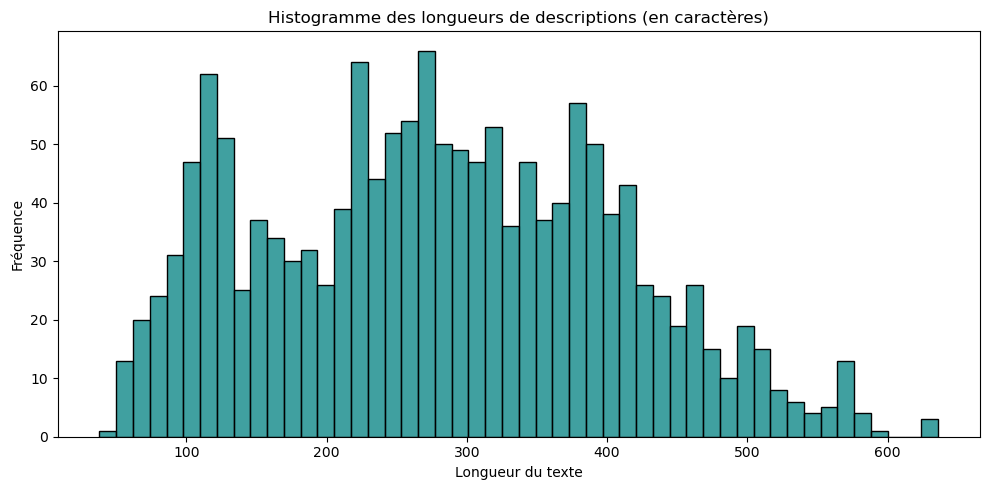

,exercise_name,execution,target_muscle,equipment,difficulty,concat_sequence,string_length
744,Jump to pull-up,"The jump to pull-up is a bodyweight exercise that targets the muscles of the back, biceps, and, to a lesser degree, legs. It involves jumping up to a pull-up bar between reps. Similar to a push-press, the legs help power through the most difficult portion of the pull-up, allowing you to perform more reps. Jumping pull-ups are often performed for moderate to high reps, such as 8-12 reps per set or more, as an accessory to other pulling or pull-up training, or as a full-body movement in a circuit or metcon.",Lats,Bodyweight,Intermediate,"The Jump to pull-up exercise for ""Lats"" with ""Bodyweight"" on ""Intermediate"" level: The jump to pull-up is a bodyweight exercise that targets the muscles of the back, biceps, and, to a lesser degree, legs. It involves jumping up to a pull-up bar between reps. Similar to a push-press, the legs help power through the most difficult portion of the pull-up, allowing you to perform more reps. Jumping pull-ups are often performed for moderate to high reps, such as 8-12 reps per set or more, as an accessory to other pulling or pull-up training, or as a full-body movement in a circuit or metcon.",510
652,Seated Leg Curl,"The leg curl is a popular machine-based exercise for the legs, particularly the hamstrings. It comes in seated and lying varieties, but the seated leg curl machine is more common in commercial gyms. Leg curl variations are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of a leg pre-exhaust or as a muscle-building movement for lower-body training.",Hamstrings,Machine,Intermediate,"The Seated Leg Curl exercise for ""Hamstrings"" with ""Machine"" on ""Intermediate"" level: The leg curl is a popular machine-based exercise for the legs, particularly the hamstrings. It comes in seated and lying varieties, but the seated leg curl machine is more common in commercial gyms. Leg curl variations are usually performed for moderate to high reps, such as 8-12 reps per set or more, as part of a leg pre-exhaust or as a muscle-building movement for lower-body training.",389
523,Cable Crossover,"The cable cross-over is an isolation movement that uses a cable stack to build bigger and stronger pectoral muscles. Since it's done using adjustable pulleys, you can target different parts of your chest by setting the pulleys at different levels. It is common in upper body and chest-focused muscle-building workouts, often as a pre-exhaust at the beginning of a workout, or a finishing movement at the end. It is often in combination with other presses or flyes to target the chest from different angles.",Chest,Cable,Intermediate,"The Cable Crossover exercise for ""Chest"" with ""Cable"" on ""Intermediate"" level: The cable cross-over is an isolation movement that uses a cable stack to build bigger and stronger pectoral muscles. Since it's done using adjustable pulleys, you can target different parts of your chest by setting the pulleys at different levels. It is common in upper body and chest-focused muscle-building workouts, often as a pre-exhaust at the beginning of a workout, or a finishing movement at the end. It is often in combination with other presses or flyes to target the chest from different angles.",506
651,Glute Ham Raise,The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD.,Hamstrings,Machine,Intermediate,"The Glute Ham Raise exercise for ""Hamstrings"" with ""Machine"" on ""Intermediate"" level: The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD.",80
1681,Decline Push-up,"Keeping body straight, lower upper body to floor by bending arms. To allow for full descent, pull head back slightly without arching back. Push body up until arms are extended. Repeat.",Pectoralis Major Clavicular,Bodyweight,Intermediate,"The Decline Push-up exercise for ""Pectoralis Major Clavicular"" with ""Bodyweight"" o

In [41]:
df_execution_generator['string_length'] = df_execution_generator['execution'].apply(len)

# Histogramme avec Seaborn
plt.figure(figsize=(10, 5))
sns.histplot(
    df_execution_generator['string_length'],
    bins=50,              # valeur raisonnable pour lisibilité
    kde=False,            # pas besoin de densité ici, mais tu peux l’activer
    color='teal',
    edgecolor='black'
)

plt.title('Histogramme des longueurs de descriptions (en caractères)')
plt.xlabel('Longueur du texte')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

# Affichage de contrôle
df_execution_generator.head()


### Calcul du nombre de mots dans chaque description 

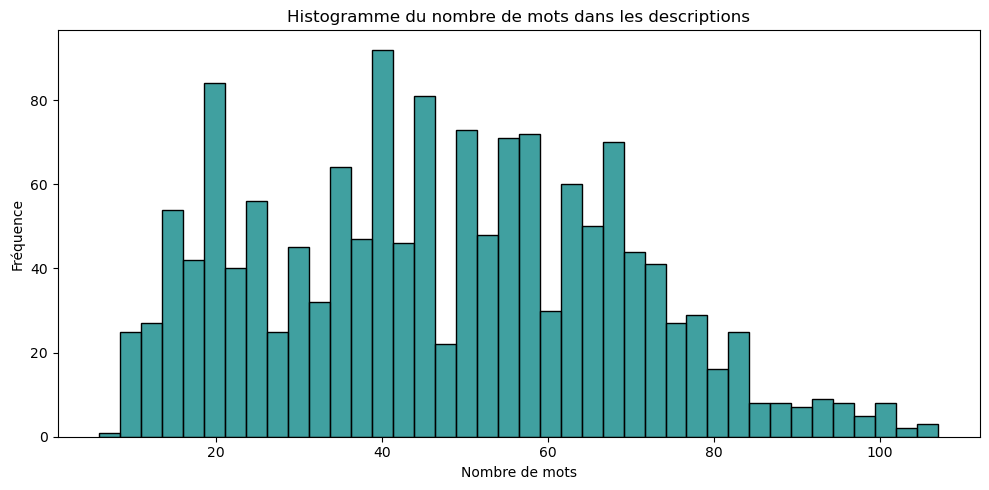

In [42]:
df_execution_generator["word_count"] = df_execution_generator["execution"].apply(
    lambda x: len(str(x).split())
)

# --- Histogramme Seaborn ---
plt.figure(figsize=(10, 5))
sns.histplot(
    df_execution_generator["word_count"],
    bins=40,                   # valeur raisonnable pour lisibilité
    kde=False,
    color="teal",
    edgecolor="black"
)

plt.title("Histogramme du nombre de mots dans les descriptions")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()


### Distribution par niveau de difficulté

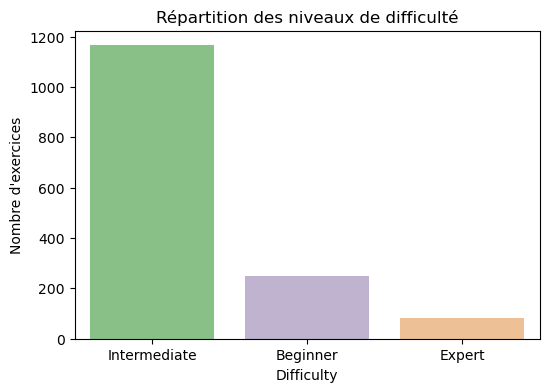

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_execution_generator, x="difficulty", palette="Accent")
plt.title("Répartition des niveaux de difficulté")
plt.xlabel("Difficulty")
plt.ylabel("Nombre d'exercices")
plt.show()


### Top 20 des muscles les plus fréquents

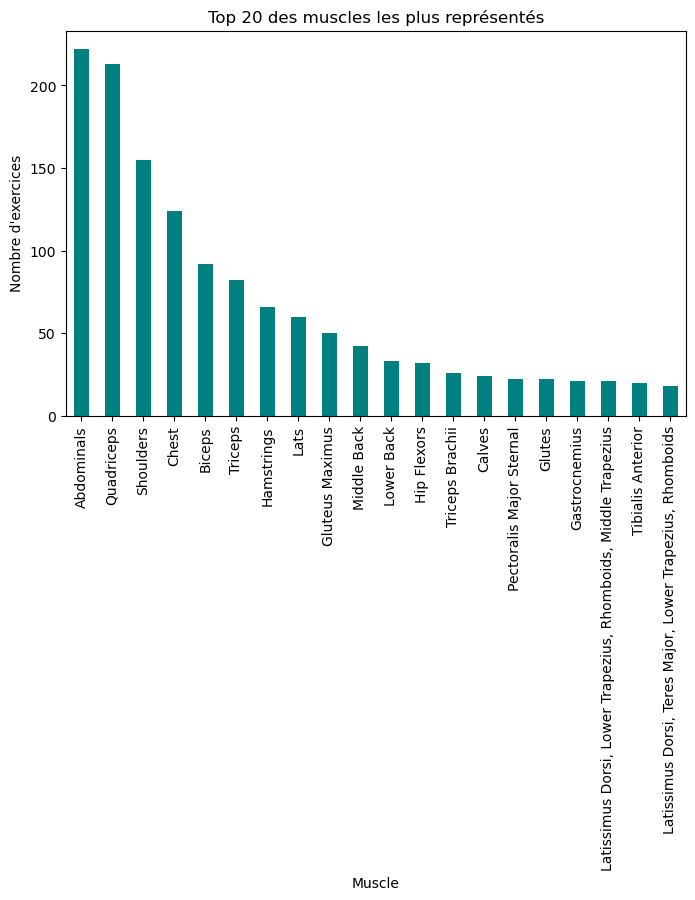

In [44]:
plt.figure(figsize=(8,5))
df_execution_generator["target_muscle"].value_counts().head(20).plot(kind="bar", color="teal")
plt.title("Top 20 des muscles les plus représentés")
plt.ylabel("Nombre d'exercices")
plt.xlabel("Muscle")
plt.tight_layout()
plt.show()


### Longueur des descriptions par muscle

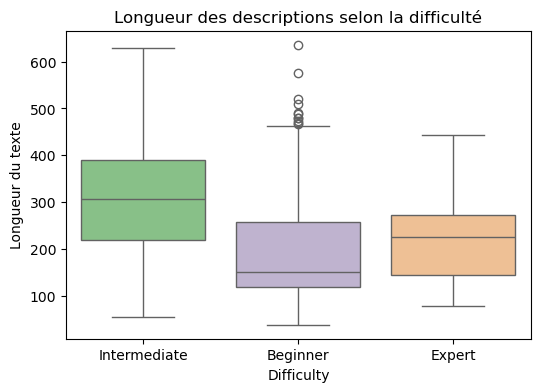

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_execution_generator,
    x="difficulty",
    y="string_length",
    palette="Accent"
)
plt.title("Longueur des descriptions selon la difficulté")
plt.xlabel("Difficulty")
plt.ylabel("Longueur du texte")
plt.show()


### Boxplot pour repérer les descriptions trop courte

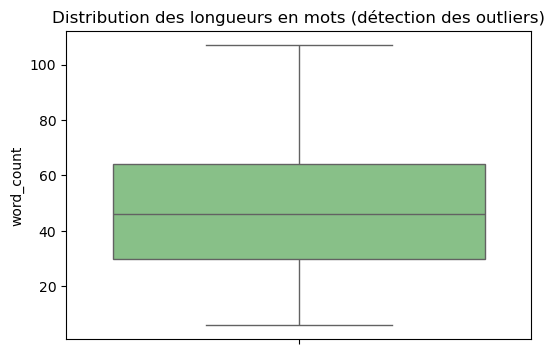

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df_execution_generator["word_count"])
plt.title("Distribution des longueurs en mots (détection des outliers)")
plt.show()


## Entraînement du modèle

### Chargement du modèle Teacher

In [47]:
# Tokenizer avec padding à gauche (utile pour le batching)
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, padding_side="left")

# Certains GPT-2-like n'ont pas de pad_token → on recycle eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Modèle PyTorch
model = AutoModelForCausalLM.from_pretrained(CHECKPOINT)
model = model.to(device)

### Vérification rapide du tokenizer et du modèle sur une phrase exemple

In [48]:
text = "This is a simple test sentence to validate the tokenizer and the model."

# Encodage du texte
encoded_input = tokenizer(
    text,
    return_tensors="pt",   # <-- sortie PyTorch
)

# Envoi optionnel sur le même device que le modèle
encoded_input = {k: v.to(device) for k, v in encoded_input.items()}

print("Tensors encodés :")
print(encoded_input)

# Passage dans le modèle (sans gradients)
with torch.no_grad():
    output = model(**encoded_input)   # <-- on transmet le dict tel quel

# Affichage de la forme des logits (batch, sequence_length, vocab_size)
print("\nShape des logits :", output.logits.shape)

Tensors encodés :
{'input_ids': tensor([[ 1212,   318,   257,  2829,  1332,  6827,   284, 26571,   262, 11241,
          7509,   290,   262,  2746,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

Shape des logits : torch.Size([1, 15, 50257])


## Pipeline initial

### Génération de texte avec le pipeline HuggingFace

In [49]:
# On utilise ici le tokenizer et le modèle déjà chargés précédemment dans le notebook.
generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1   # 0 = GPU, -1 = CPU
)

# --- Rendre la génération déterministe ---
set_seed(42)

# On prend les lignes 3 à 6 (incluses), c’est-à-dire les index 3, 4, 5, 6
sample_prompts = df_execution_generator["concat_sequence"].iloc[3:7].tolist()

print("Prompts sélectionnés :")
for i, p in enumerate(sample_prompts, 1):
    print(f"\n--- PROMPT {i} ---\n{p}")

# --- Génération pour chaque prompt ---
generated_outputs = []

for prompt in sample_prompts:
    outputs = generator(
        prompt,
        max_length=64,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_outputs.append(outputs[0]["generated_text"])

# --- Affichage ---
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(generated_outputs, 1):
    print(f"\n===== OUTPUT {i} =====")
    print(text)

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompts sélectionnés :

--- PROMPT 1 ---
The Glute Ham Raise exercise for "Hamstrings" with "Machine" on "Intermediate" level: The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD.

--- PROMPT 2 ---
The Decline Push-up exercise for "Pectoralis Major Clavicular" with "Bodyweight" on "Intermediate" level: Keeping body straight, lower upper body to floor by bending arms. To allow for full descent, pull head back slightly without arching back. Push body up until arms are extended. Repeat.

--- PROMPT 3 ---
The One Handed Hang exercise for "Lats" with "Bodyweight" on "Intermediate" level: The single-arm hang is a static exercise that involves hanging from a bar by one hand. It is an advanced hanging exercise that demands above-average shoulder stability and grip strength, and may not be appropriate for some people. However, if someone is strong and stable enough to perform it, the movement can help build those same qualities.

--- PROMPT 4 ---
The Warrior push-up 

Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
The Glute Ham Raise exercise for "Hamstrings" with "Machine" on "Intermediate" level: The glute ham raise is an exercise targeting the glutes and hamstrings on a GHD.Fitness scale

===== OUTPUT 2 =====
The Decline Push-up exercise for "Pectoralis Major Clavicular" with "Bodyweight" on "Intermediate" level: Keeping body straight, lower upper body to floor by bending arms. To allow for full descent, pull head back slightly without arching back. Push body up until arms are extended. Repeat. fully retracted.

===== OUTPUT 3 =====
The One Handed Hang exercise for "Lats" with "Bodyweight" on "Intermediate" level: The single-arm hang is a static exercise that involves hanging from a bar by one hand. It is an advanced hanging exercise that demands above-average shoulder stability and grip strength, and may not be appropriate for some people. However, if someone is strong and stable enough to perform it, the

In [50]:
# On prend les lignes 13 à 16 incluses (index 13 → 16)
sample_prompts = df_execution_generator["concat_sequence"].iloc[13:17].tolist()

print("Prompts sélectionnés :")
for i, p in enumerate(sample_prompts, 1):
    print(f"\n--- PROMPT {i} ---\n{p}")

# --- Génération pour chaque prompt ---
generated_outputs = []

for prompt in sample_prompts:
    outputs = generator(
        prompt,
        max_length=64,
        num_return_sequences=1,
        pad_token_id=tokenizer.eos_token_id
    )
    generated_outputs.append(outputs[0]["generated_text"])

# --- Affichage ---
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(generated_outputs, 1):
    print(f"\n===== OUTPUT {i} =====")
    print(text)


Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompts sélectionnés :

--- PROMPT 1 ---
The Band Pull Apart exercise for "Shoulders" with "Bands" on "Intermediate" level: The band pull-apart is an exercise targeting the upper back muscles, including the trapezius, rear delts, and rhomboids. The band creates dynamic tension, allowing you to really focus on contracting these muscles, making it a great activation drill prior to upper-body lifting.

--- PROMPT 2 ---
The Alligator Crawl exercise for "Abdominals" with "Bodyweight" on "Intermediate" level: The spider crawl is a bodyweight exercise that involves crawling on the floor with the knees outside of the elbows. It is different from a leopard crawl in that the hips are higher, and it's different from a bear crawl because the knees are wider. It can be done as a full-body warm-up, in short bursts for power or circuit training, or for longer durations as cardiovascular conditioning.

--- PROMPT 3 ---
The Glute-Ham Raise exercise for "Hamstrings" with "Bodyweight" on "Expert" level: 

Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=64) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
The Band Pull Apart exercise for "Shoulders" with "Bands" on "Intermediate" level: The band pull-apart is an exercise targeting the upper back muscles, including the trapezius, rear delts, and rhomboids. The band creates dynamic tension, allowing you to really focus on contracting these muscles, making it a great activation drill prior to upper-body lifting. it.

===== OUTPUT 2 =====
The Alligator Crawl exercise for "Abdominals" with "Bodyweight" on "Intermediate" level: The spider crawl is a bodyweight exercise that involves crawling on the floor with the knees outside of the elbows. It is different from a leopard crawl in that the hips are higher, and it's different from a bear crawl because the knees are wider. It can be done as a full-body warm-up, in short bursts for power or circuit training, or for longer durations as cardiovascular conditioning. not

===== OUTPUT 3 =====
The Glute-Ham Raise 

## Preparation des données pour le fine-tuning

### Tokenisation du corpus complet

In [51]:
tokenized_data = tokenizer.batch_encode_plus(
    df_execution_generator["concat_sequence"].tolist(),
    return_tensors="pt",     # <-- sortie au format PyTorch
    padding=True,            # pad automatique pour uniformiser les batchs
    truncation=True,         # coupe les séquences trop longues
    max_length=MAX_LENGTH,   # longueur maximale autorisée
)

# Envoi des tenseurs sur le device (GPU si dispo, sinon CPU)
tokenized_data = {k: v.to(device) for k, v in tokenized_data.items()}

### Affichage des données tokenisées

In [52]:
print("Input IDs :")
print(tokenized_data["input_ids"])

print("\nAttention Mask :")
print(tokenized_data["attention_mask"])

Input IDs :
tensor([[50256, 50256, 50256,  ...,  1138,  1102,    13],
        [50256, 50256, 50256,  ...,  2618,  3047,    13],
        [50256, 50256, 50256,  ...,  1180, 18333,    13],
        ...,
        [50256, 50256, 50256,  ..., 10581,  1249,    13],
        [50256, 50256, 50256,  ...,    13, 30021,    13],
        [50256, 50256, 50256,  ...,  1180,  5642,    13]])

Attention Mask :
tensor([[0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        ...,
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1],
        [0, 0, 0,  ..., 1, 1, 1]])


### Inspection des types des objets manipulés

In [53]:
print("Type de tokenized_data :", type(tokenized_data))        # BatchEncoding / dict
print("Type de tokenized_data['input_ids'] :", type(tokenized_data["input_ids"]))  # torch.Tensor

# Affichage du premier exemple tokenisé (une ligne du dataset)
print("\nPremier input_ids tokenisé :")
print(tokenized_data["input_ids"][:1])

# Clés disponibles dans la structure
print("\nClés présentes dans tokenized_data :", tokenized_data.keys())

Type de tokenized_data : <class 'dict'>
Type de tokenized_data['input_ids'] : <class 'torch.Tensor'>

Premier input_ids tokenisé :
tensor([[50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256,   464, 15903,   284,  2834,    12,   929,
          5517,   329,   366,    43,  1381,     1,   351,   366, 25842,  6551,
             1,   319,   366,  9492, 13857,     1,  1241,    25,   383,  4391,
           284,  2834,    12,   929,   318,   257,  1767,  6551,  5517,   326,
          6670,   262, 12749,   286,   262,   736,    11,   275, 41663,    11,
           290,    11,   284,   257, 14494,  4922,    11,  7405,    13,   632,
          9018, 14284,   510,   284,   257,  2834,    12,   929,  2318,  1022,
         20982,    13, 11014,   284,   257,  4574,    12,  8439,    11,   262,
          7405,  1037,  1176,   832,   262,   749,  2408,  6903,   286,   262,


## Dataset PyTorch

In [54]:
dataset = TensorDataset(
    tokenized_data["input_ids"],
    tokenized_data["attention_mask"],
    tokenized_data["input_ids"]    # labels
)

# --- Création du DataLoader (batches de BATCH_SIZE) ---
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,     # variable globale
    shuffle=True               # important pour l'entraînement
)

print(f"Nombre total de batches : {len(dataloader)}")

Nombre total de batches : 188


### Construire un Dataset PyTorch

In [55]:
class CausalDataset(Dataset):
    def __init__(self, tokenized_data):
        self.input_ids = tokenized_data["input_ids"]
        self.attention_mask = tokenized_data["attention_mask"]

    def __len__(self):
        return self.input_ids.size(0)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            # labels = input_ids pour modèle causale GPT/DistilGPT2
            "labels": self.input_ids[idx],
        }

dataset = CausalDataset(tokenized_data)


### Construire un DataLoader PyTorch

In [56]:
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

### Vérification du batch

In [57]:
batch = next(iter(dataloader))
for k, v in batch.items():
    print(k, v.shape)

input_ids torch.Size([8, 172])
attention_mask torch.Size([8, 172])
labels torch.Size([8, 172])


### Examiner le premier batch

In [58]:
first_batch = next(iter(dataloader))

# Extraction via les clés du dictionnaire
input_ids = first_batch["input_ids"]
attention_mask = first_batch["attention_mask"]
labels = first_batch["labels"]

# On examine seulement le premier exemple
i = 0
print("Input IDs :", input_ids[i])
print("Texte décodé (input) :", tokenizer.decode(input_ids[i], skip_special_tokens=False))

print("\nAttention Mask :", attention_mask[i])

print("\nLabels IDs :", labels[i])
print("Texte décodé (labels) :", tokenizer.decode(labels[i], skip_special_tokens=False))

print("=" * 50)

Input IDs : tensor([50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
          464,  2677, 21521,  2409,  7923, 16283,  5819,  5517,   329,   366,
        19926,   364,     1,   351,   366, 10374,  7923,     1,   319,   366,
         9492, 13857,     1,  1241,    25,   383,  2318,  7923,  5636,  5819,
          318,   257,  1336,    12,  2618,  5517,   326, 33181,  1111, 22713,
          889,   290, 12273,   287,   530, 10345,  3356,    13,   632,   338,
         2592,  2219,   287, 11811,  6372, 31805, 27197,    11,   475,   635,
          287,  2276,  4202,  3047,    13,   383,  2318,  7923,   318,  3221,
        20750,   656,  1295,   717,    11,   475,   

## Train / Validation split

In [59]:
# --- Nombre total d'exemples dans le dataset ---
num_samples = len(dataset)
print(f"Nombre total d'exemples : {num_samples}")

# --- Nombre approximatif de batches ---
num_batches = math.ceil(num_samples / BATCH_SIZE)
print(f"{num_batches} batches de {BATCH_SIZE} exemples chacun.")

# --- Split 90% / 10% ---
train_size = int(0.9 * num_samples)
val_size = num_samples - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Taille du jeu d'entraînement : {train_size}")
print(f"Taille du jeu de validation : {val_size}")

# --- DataLoaders ---
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,   # important pour le training
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # on ne shuffle pas la validation
)

Nombre total d'exemples : 1497
188 batches de 8 exemples chacun.
Taille du jeu d'entraînement : 1347
Taille du jeu de validation : 150


## Configuration et compilation du modèle

### Optimiseur et scheduler

In [60]:
print(f"Nombre d'époques : {EPOCHS}")

# Nombre de batches par époque × nombre d'époques
num_update_steps_per_epoch = len(train_dataloader)
num_training_steps = num_update_steps_per_epoch * EPOCHS
print(f"Nombre total de training steps : {num_training_steps}")

# On utilise AdamW comme dans les entraînements GPT-2 officiels
optimizer = AdamW(model.parameters(), LR)

# Scheduler du taux d’apprentissage
# Scheduler linéaire = décroissance progressive du LR jusqu'à 0,
# équivalent à ton PolynomialDecay TensorFlow avec end_learning_rate = 0.
lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,          # pas de warmup pour l’instant
    num_training_steps=num_training_steps,
)

print("Optimiseur et scheduler LR initialisés.")

Nombre d'époques : 12
Nombre total de training steps : 2028
Optimiseur et scheduler LR initialisés.


### Chargement de la configuration du modèle HuggingFace

In [61]:
config = AutoConfig.from_pretrained(CHECKPOINT)
print(config)

GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 1280,
  "n_head": 20,
  "n_inner": null,
  "n_layer": 36,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "conversational": {
      "max_length": 1000
    }
  },
  "transformers_version": "4.57.3",
  "use_cache": true,
  "vocab_size": 50257
}



### Récupération d’un batch d’entraînement et passage avant (forward pass)

In [62]:
batch = next(iter(train_dataloader))
batch = {k: v.to(device) for k, v in batch.items()}

outputs = model(**batch)

loss = outputs.loss
logits = outputs.logits

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


### Comptage des paramètres du modèle

In [63]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Nombre total de paramètres       : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")

Nombre total de paramètres       : 774,030,080
Nombre de paramètres entraînables : 774,030,080


## Entraînement du modèle

### Callback pour afficher le Learning Rate à chaque époque

In [64]:
class PrintLearningRate:
    def on_epoch_begin(self, epoch, optimizer):
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch + 1} — Learning Rate : {lr}")


### Callback d'affichage de l'évolution de la loss

In [65]:
class FineTuneVisualizer:
    """
    Visualisation dynamique du fine-tuning :
      - Courbe des losses train / val par époque
      - Barres avant / après pour l'amélioration globale
    """

    def __init__(self, total_epochs: int):
        self.total_epochs = total_epochs
        self.train_losses = []
        self.val_losses = []

    def update(self, epoch: int, train_loss: float, val_loss: float):
        # On stocke les nouvelles valeurs
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

        # Rafraîchissement propre dans le notebook
        clear_output(wait=True)

        # --- Graphiques ---
        plt.figure(figsize=(14, 5))

        # 1) Courbe des pertes (train / val)
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, "o-", label="Train Loss")
        plt.plot(self.val_losses, "o-", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Progression du fine-tuning GPT (TrAIn.me Execution Generator)", fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend()

        # 2) Aperçu de l'amélioration globale
        plt.subplot(1, 2, 2)
        if len(self.train_losses) > 1:
            improvement = ((self.train_losses[0] - self.train_losses[-1]) /
                           self.train_losses[0]) * 100
            plt.bar(
                ["Initial", "Actuel"],
                [self.train_losses[0], self.train_losses[-1]],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
            )
            plt.title(f"Amélioration : {improvement:.1f}%", fontsize=14)
            plt.ylabel("Loss")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        # Log textuel
        print(f"Epoch {epoch + 1}/{self.total_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")

### Boucle d'entraînement

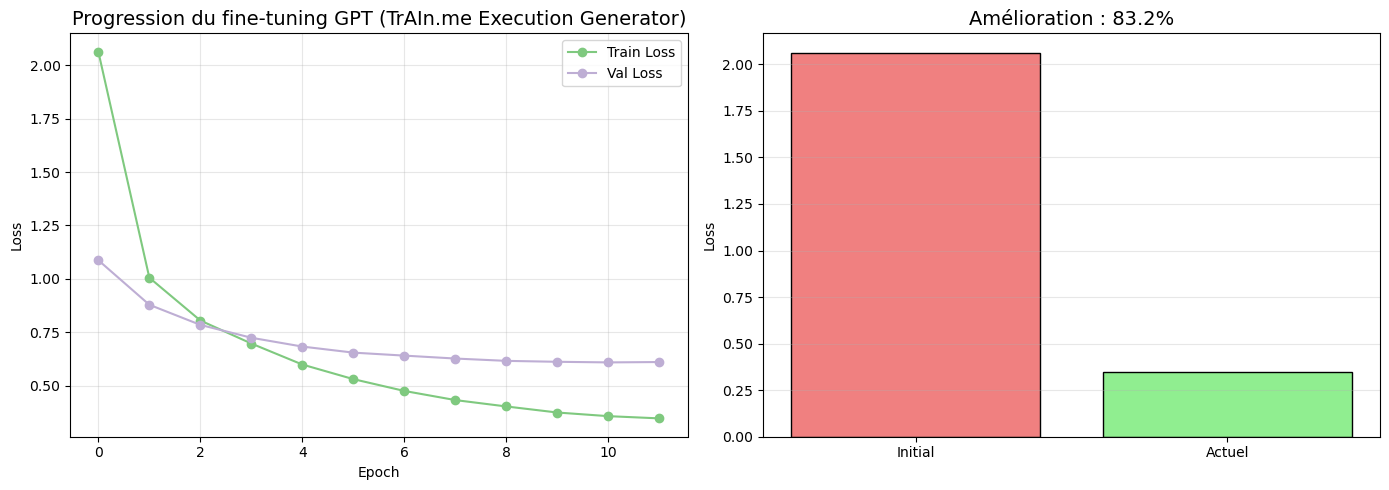

Epoch 12/12
Train Loss : 0.3471 | Val Loss : 0.6108


In [66]:
lr_callback = PrintLearningRate()
visualizer = FineTuneVisualizer(total_epochs=EPOCHS)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # === LR callback ===
    lr_callback.on_epoch_begin(epoch, optimizer)

    # =============== TRAIN LOOP ===============
    model.train()
    running_train_loss = 0.0

    progress_bar = tqdm(train_dataloader, desc=f"Train epoch {epoch+1}", leave=False)

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

        running_train_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

    avg_train_loss = running_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # =============== VAL LOOP ===============
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    # === Mise à jour du visualizer ===
    visualizer.update(epoch, avg_train_loss, avg_val_loss)


## Tests de génération

### Reconstuction des prompts

In [67]:
# Même logique de prompt pour le dataset de validation sans "execution"
df_best_50_exercise_for_your_body["prompts"] = df_best_50_exercise_for_your_body.apply(
    lambda x: 
        f'The {x["exercise_name"].strip()} exercise for '
        f'"{x["target_muscle"].strip()}" with '
        f'"{x["equipment"].strip()}" on '
        f'"{x["difficulty"].strip()}" level:',
    axis=1
)

# On prend les lignes 1 à 3 du dataset de validation final
sample_prompts = df_best_50_exercise_for_your_body["prompts"].iloc[1:4].tolist()
print(sample_prompts)

['The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:', 'The Push-ups (Shoulders) exercise for "Shoulders" with "Bodyweight" on "Intermediate" level:', 'The Squats (Quadriceps) exercise for "Quadriceps" with "Bodyweight" on "Beginner" level:']


### Tokenisation d’une liste de prompts

In [68]:
encodings = tokenizer(
    sample_prompts, # liste de phrases (lignes 20 à 23)
    return_tensors="pt", # sortie PyTorch
    padding=True, # pad à gauche (défini plus tôt)
    truncation=True # coupe si dépasse max_length défini pour le tokenizer
).to(device) # on place le tout sur CPU ou GPU selon config

### Fonction de suppression du prompt dans chaque génération

In [69]:
def strip_prompt_from_generations(prompts, generated_outputs):
    """
    Supprime le prompt au début de chaque génération si le modèle l'a recopié.
    """
    
    cleaned = []
    
    for prompt, gen in zip(prompts, generated_outputs):
        gen_strip = gen.strip()
        
        if gen_strip.startswith(prompt):
            cleaned.append(gen_strip[len(prompt):].strip())
        else:
            cleaned.append(gen_strip)
    
    return cleaned


### Fonction pour tronquer le texte à la dernière phrase complète

In [70]:
def trim_to_last_full_sentence(text: str) -> str:
    """
    Coupe le texte à la dernière phrase complète.
    On garde tout jusqu'au dernier '.', '!' ou '?'.
    Si aucun n'est trouvé, on renvoie le texte brut stripé.
    """
    text = text.strip()

    last_dot = text.rfind(".")
    last_excl = text.rfind("!")
    last_q = text.rfind("?")

    last_punct = max(last_dot, last_excl, last_q)

    if last_punct != -1:
        return text[: last_punct + 1].strip()
    return text


### Fonction pour limiter la longueur “perçue” par phrase

In [71]:
def keep_first_n_sentences(text: str, n: int = 2) -> str:
    # Split grossier sur . ! ?
    sentences = re.split(r'([.!?])', text)
    chunks = []
    count = 0

    for i in range(0, len(sentences) - 1, 2):
        sentence = sentences[i].strip()
        punct = sentences[i + 1].strip()
        if sentence:
            chunks.append(sentence + punct)
            count += 1
        if count >= n:
            break

    return " ".join(chunks).strip() if chunks else text.strip()


### Fonction pour dédupliquer les muscles dans le texte

In [72]:
def dedupe_muscle_list(text: str) -> str:
    """
    Détecte les listes du type 'glutes, hamstrings, and hamstrings'
    dans la phrase, les déduplique et les reformate proprement.
    """

    # Regex qui capture une liste séparée par virgules ou 'and'
    # Exemple capturé : "glutes, hamstrings, and hamstrings"
    pattern = r"([A-Za-z ]+(?:,\s*[A-Za-z ]+)*(?:\s+and\s+[A-Za-z ]+)?)"

    def process_match(match):
        segment = match.group(0)

        # Split sur virgules et 'and'
        parts = re.split(r",|\band\b", segment)
        parts = [p.strip() for p in parts if p.strip()]

        # Déduplique tout en gardant l’ordre
        seen = set()
        unique = []
        for p in parts:
            if p.lower() not in seen:
                seen.add(p.lower())
                unique.append(p)

        # Reconstruction naturelle
        if len(unique) == 1:
            return unique[0]

        if len(unique) == 2:
            return f"{unique[0]} and {unique[1]}"

        return ", ".join(unique[:-1]) + f", and {unique[-1]}"

    # Applique la fonction sur toutes les occurrences
    cleaned = re.sub(pattern, process_match, text)
    return cleaned


### Fonction de nettoyage “cosmétique”

In [73]:
def clean_execution_text(text: str) -> str:
    if not isinstance(text, str):
        return text

    cleaned = text

    # 1) Ajouter un espace après un point si collé à une majuscule
    cleaned = re.sub(r'(\.)([A-Z])', r'\1 \2', cleaned)

    # 2) Ajouter un espace après "such as" si collé à un chiffre
    cleaned = re.sub(r"(such as)(\d)", r"\1 \2", cleaned)

    # 3) Ajouter un espace avant "reps" si collé au chiffre
    cleaned = re.sub(r"(\d)(reps)", r"\1 reps", cleaned)

    # 4) Normaliser les doubles espaces
    cleaned = re.sub(r"\s{2,}", " ", cleaned).strip()

    return cleaned

### Greedy Search
Greedy Search génère du texte en choisissant à chaque étape le token ayant la probabilité la plus élevée, ce qui rend la sortie déterministe mais parfois peu créative.

In [74]:
# Génération de texte avec le modèle distillé
outputs = model.generate(
    **encodings,                   # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH,     # nombre maximum de tokens générés
    min_new_tokens=20,             # forcé pour éviter les générations vides
    pad_token_id=tokenizer.eos_token_id,
)

# Décodage propre du batch → conversion des tokens en texte lisible
generated_outputs = tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)



=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Beam Search
Beam Search explore plusieurs suites de tokens en parallèle et ne conserve que les plus prometteuses, ce qui produit des textes plus cohérents et globablement meilleurs qu’un greedy pur.

In [75]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH,# nombre maximum de tokens générés
    num_beams=5, # beam search pour améliorer la cohérence
    do_sample=True, # sampling activé pour ajouter de la diversité
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt si tous les beams atteignent EOS
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### n-gram Penalties
Les n-gram penalties empêchent le modèle de réutiliser plusieurs fois la même séquence de n tokens, réduisant ainsi les répétitions et rendant la génération plus fluide.

In [76]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    num_beams=5, # beam search pour améliorer la cohérence
    do_sample=True, # sampling activé pour ajouter de la diversité
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt si tous les beams atteignent EOS
    no_repeat_ngram_size=2, # empêche les répétitions de 2-gram
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)



=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Sampling
Sampling sélectionne chaque token aléatoirement selon la distribution de probabilités du modèle, ce qui produit des textes plus variés et créatifs qu'une stratégie déterministe.

In [77]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Tweak the Temperature
Ajuster la temperature revient à rendre la distribution des probabilités plus plate (créatif) ou plus pointue (strict), influençant directement le niveau de diversité dans la génération.

In [78]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    temperature=0.6, # modifie la "chaleur" de la distribution
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Top-K Sampling
Top-K Sampling limite le choix du modèle aux K tokens les plus probables, équilibrant aléatoire et contrôle pour éviter des choix trop improbables.

In [79]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    top_k=50, # top-K sampling (limite aux 50 tokens les plus probables)
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Top-P (Nucleus) Sampling
Top-P (Nucleus) Sampling sélectionne les tokens au sein de la plus petite portion cumulative de probabilité P, garantissant diversité et cohérence en ne gardant que les choix réellement plausibles du modèle.

In [80]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    top_p=0.92, # nucleus sampling (top-P)
    pad_token_id=tokenizer.eos_token_id,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Putting It All Together
Consiste à combiner plusieurs techniques de génération (greedy, sampling, top-k, top-p, pénalités, beam…) pour obtenir un comportement équilibré entre cohérence, contrôle et créativité.

In [81]:
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    do_sample=True, # sampling activé pour ajouter de la diversité
    top_k=250, # top-K sampling large
    top_p=0.92, # nucleus sampling
    no_repeat_ngram_size=3, # évite les répétitions de 3-gram
    num_beams=5, # beam search pour améliorer la cohérence
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt anticipé si EOS atteint sur tous les beams
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs
)

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i-1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps as part of a larger upper-body or arm-focused workout. Many lifters find that it can be a great accessory movement to the push-up: the push-up or the pull-up itself. It can be performed for reps in a circuit or for time or for reps as part of a larger upper-body workout. It can be performed for reps or as a single-body or arm-focused workout. It can be performed for reps in a circuit or as part of a larger circuit or flow. It can be performed for reps in a fat-loss or flow or flow or flow. It can be performed for reps in a warm-up or as a circuit or flow or flow. It can be per

### Optimisations 1


In [82]:
# Génération de texte avec réglages avancés
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    min_new_tokens=40, # longueur minimale pour éviter les textes trop courts
    do_sample=True, # sampling activé (obligatoire pour top-k / top-p)
    temperature=0.8, # légère "chauffe" pour plus de variété
    top_k=250, # top-K sampling large
    top_p=0.92, # nucleus sampling
    no_repeat_ngram_size=3, # évite les répétitions de 3-grams
    num_beams=5, # beam search pour améliorer la cohérence
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt anticipé si EOS atteint partout
)

# Décodage propre du batch → texte lisible
generated_outputs = tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True,
)

# Suppression du prompt dans chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs,
)


# Coupe chaque génération à la dernière phrase complète
final_generations = [trim_to_last_full_sentence(txt) for txt in cleaned_generations]

# Affichage des générations
print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(cleaned_generations, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i - 1])
    print(text)



=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the tricep muscles. It is usually performed for moderate to high reps, such as 8-12 reps per set, as part of an upper-body or arm-focused workout. It can be performed for time or reps in the main part of any workout. Many lifters find it to be a great way to burn serious calories. Like most people on this sub, it is often performed with bodyweight circuit-style training.

===== OUTPUT 2 =====
Prompt: The Push-ups (Shoulders) exercise for "Shoulders" with "Bodyweight" on "Intermediate" level:
The push-up is a bodyweight exercise that targets the muscles of the upper back, including the lats (latissimus dorsi), traps, rhomboids, and rear deltoids. It can be performed for time or reps in the core-focused portion of any workout. It is usually performed f

### Optimisations 2


In [83]:
# 1. Génération
outputs = model.generate(
    **encodings, # batch de prompts déjà tokenisés
    max_new_tokens=MAX_LENGTH, # nombre maximum de tokens générés
    min_new_tokens=50, # longueur minimale pour éviter les textes trop courts
    do_sample=True, # sampling activé (obligatoire pour top-k / top-p)
    temperature=0.8, # légère "chauffe" pour plus de variété
    top_k=250, # top-K sampling large
    top_p=0.92, # nucleus sampling
    no_repeat_ngram_size=3, # évite les répétitions de 3-grams
    num_beams=5, # beam search pour améliorer la cohérence
    num_return_sequences=1, # une seule génération par prompt
    pad_token_id=tokenizer.eos_token_id,
    early_stopping=True, # arrêt anticipé si EOS atteint partout
)

generated_outputs = tokenizer.batch_decode(
    outputs,
    skip_special_tokens=True,
)

# 2. On enlève le prompt au début de chaque génération
cleaned_generations = strip_prompt_from_generations(
    prompts=sample_prompts,
    generated_outputs=generated_outputs,
)

# 3. Post-traitement en pipeline, **élément par élément**
# Post-traitement
trimmed  = [trim_to_last_full_sentence(txt) for txt in cleaned_generations]
limited  = [keep_first_n_sentences(t, n=2) for t in trimmed]
deduped  = [dedupe_muscle_list(t) for t in limited]
final    = [clean_execution_text(t) for t in deduped]

print("\n=================== RÉSULTATS DE GÉNÉRATION ===================\n")
for i, text in enumerate(final, 1):
    print(f"\n===== OUTPUT {i} =====")
    print("Prompt:", sample_prompts[i - 1])
    print(text)


=================== RÉSULTATS DE GÉNÉRATION ===================


===== OUTPUT 1 =====
Prompt: The Push-ups (Triceps) exercise for "Triceps" with "Bodyweight" on "Intermediate" level:
The push-up is a popular bodyweight exercise targeting the triceps. It is usually performed for moderate to high reps and such as 8-12 reps per set and as part of an upper-body or arm-focused workout.

===== OUTPUT 2 =====
Prompt: The Push-ups (Shoulders) exercise for "Shoulders" with "Bodyweight" on "Intermediate" level:
The push-up is a bodyweight exercise that targets the muscles of the upper back and including the lats(latissimus dorsi),traps, rhomboids, and rear deltoids. It can be performed for time or reps in the core-focused portion of any workout.

===== OUTPUT 3 =====
Prompt: The Squats (Quadriceps) exercise for "Quadriceps" with "Bodyweight" on "Beginner" level:
Squat down by bending hips back while allowing knees to bend forward slightly, keeping back straight, and knees pointed same directio

## Sauvegarde du modèle distillé (format HuggingFace)

In [84]:
# Chemin du notebook courant
notebook_dir = Path().resolve()

# Racine du projet : notebooks/... → remonter 3 niveaux
project_root = notebook_dir.parent.parent.parent

# Dossier final où stocker ton modèle distillé
save_dir = project_root / "models" / OUTPUT_MODEL_NAME
save_dir.mkdir(parents=True, exist_ok=True)

print(f"Sauvegarde du modèle dans : {save_dir}")

# Sauvegarde du modèle PyTorch HF
model.save_pretrained(save_dir)

# Sauvegarde du tokenizer associé
tokenizer.save_pretrained(save_dir)

# Vérification
print("\nContenu du dossier sauvegardé :")
for f in save_dir.iterdir():
    print("   -", f.name)

Sauvegarde du modèle dans : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\transformer_execution_generator_v6

Contenu du dossier sauvegardé :
   - chat_template.jinja
   - config.json
   - generation_config.json
   - merges.txt
   - model.safetensors
   - special_tokens_map.json
   - tokenizer.json
   - tokenizer_config.json
   - vocab.json


## Informations relatives au modèle (son nom et les métriques associées)

In [85]:
print("\n===== EXECUTION GENERATOR — MODEL REPORT =====\n")

# Répertoire du modèle (même dossier que la sauvegarde)
model_dir = save_dir                      # défini lors de save_pretrained(...)
report_path = model_dir / "execution_generator_model_report.json"

# Récupération des métriques
final_train_loss = float(train_losses[-1]) if train_losses else None
final_val_loss   = float(val_losses[-1]) if val_losses else None
best_val_loss    = float(min(val_losses)) if val_losses else None

# On prend comme "best_loss" la meilleure val_loss si dispo, sinon la dernière train_loss
if best_val_loss is not None:
    best_loss = best_val_loss
else:
    best_loss = final_train_loss

# Taille du modèle
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_mb = total_params * 4 / (1024**2)   # float32 supposé

# Contexte d’évaluation
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling",
    "target": "next_token_prediction (execution_generation)",
    "n_train_samples": int(len(train_dataset)) if "train_dataset" in globals() else None,
    "n_val_samples": int(len(val_dataset)) if "val_dataset" in globals() else None,
    "sequence_length": int(MAX_LENGTH),
    "device": str(device),

    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "CausalLM_FineTuned",
        "class": model.__class__.__name__,
        "checkpoint_base": CHECKPOINT,
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "size_mb": round(size_mb, 2),
    },

    "training": {
        "epochs": int(EPOCHS),
        "learning_rate": float(LR),
        "batch_size": int(BATCH_SIZE),
        "seed_global": int(SEED_GLOBAL),
        "optimizer": "AdamW",
    },

    "metrics": {
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_loss": best_val_loss,
        "best_loss": best_loss,
    },
}

# Impression console

for section, value in report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

# Enregistrement JSON
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nRapport JSON enregistré : {report_path}")



===== EXECUTION GENERATOR — MODEL REPORT =====

- created_at: 2025-12-10T18:03:11.475231Z
- task: language_modeling
- target: next_token_prediction (execution_generation)
- n_train_samples: 1347
- n_val_samples: 150
- sequence_length: 256
- device: cpu
- model:
    • name: transformer_execution_generator_v6
    • type: CausalLM_FineTuned
    • class: GPT2LMHeadModel
    • checkpoint_base: microsoft/DialoGPT-large
    • total_params: 774030080
    • trainable_params: 774030080
    • size_mb: 2952.69
- training:
    • epochs: 12
    • learning_rate: 2e-05
    • batch_size: 8
    • seed_global: 42
    • optimizer: AdamW
- metrics:
    • final_train_loss: 0.3470655633853032
    • final_val_loss: 0.6107871328529558
    • best_val_loss: 0.6090954165709647
    • best_loss: 0.6090954165709647

Rapport JSON enregistré : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\transformer_execution_generator_v6\execution_generator_model_report.json


## Notes
Renseigner "target_muscles" et "equipment" en plus --> OK

Revoir la fusion des données pour améliorer la description --> OK

Eviter que les phrases de fin se coupent. --> OK

### **Optimisations 1**
1️⃣ Activer no_repeat_ngram_size=3 ou 4 --> OK

→ casse immédiatement les répétitions (“warm-up warm-up warm-up”).

2️⃣ Utiliser top-p sampling + légère temperature --> OK

→ variantes plus naturelles.

3️⃣ Ajouter min_new_tokens=40 ou 50 --> OK

→ descriptions plus complètes.

4️⃣ Nettoyer ton corpus des répétitions internes

→ éviter que le modèle n’apprenne des patterns cycliques.

5️⃣ Continuer l’entraînement 1 à 3 epochs de plus --> OK

→ stabilisation du style.

6️⃣ Option : affiner l’entraînement sur un corpus encore plus propre

→ moins bruité = meilleure cohérence.




### **Optimisations 2**

1️⃣ Dédupliquer les muscles dans le texte --> OK

2️⃣ Limiter la longueur “perçue” par phrase --> OK

Changer de modèle à distiller "distillgpt2" > "gpt2"